In [149]:
#+++ версия 2025.04.14 tg: Цифриум, команда 2 Машинисты, @codeup1054, @Kimutogo,@Eques8, @serin_1995, @saturnian1, @tyuop077
from importlib import reload
import sys, os 
import ipynbname


current_dir = os.getcwd()

for i in ['utils_log','datetime','glob']:
    if i in sys.modules: del  sys.modules[i] 
    exec (f'from {i} import *')  
    
    
tm()

i = 0
for k in dir(ps):
    if ('_' not in k) and isinstance(getattr(ps, k), str) :
        print (f"{getattr(ps, k)}{k:^9}{ps._} ", end="")
        if (i := i+1)%10 == 0 : print("")

dfr = dfr if 'dfr' in vars() else {}

print ("\n")

NB_PATH_NAME = ipynbname.path().name
LOG_SHEET_NAME = NB_PATH_NAME

tg(f"🧠 Start | {LOG_SHEET_NAME} ", sheet_name=LOG_SHEET_NAME)

tm('>>>')   

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'



 *** Start at: 07:33:41 2025-04-27  ****************************************
  BBLUE     BDRED     BGOLD     BGRAY    BGREEN    BLBLUE    BLCYAN    BLGRAY    BLGREEN   BLILAC   
 BLLBLUE  BLMAGENTA BLORANGE    BLRED     BLUE       BLY    BLYELLOW  BMAGENTA    BOLD     BORANGE  
  BRED     BWHITE      BY      BYELLOW    CYAN    DARKCYAN      E        END       ERR      GOLD    
  GRAY      GREEN     LBLUE     LGRAY    LGREEN   LMAGENTA    LRED     MAGENTA   ORANGE    PURPLE   
   RED        T       TOTAL   UNDERLINE   WHITE       Y      YELLOW      err    

  0:00:04.676  ₀⡄₀₀⡄₀₄.₆₇₆ >>>


datetime.datetime(2025, 4, 27, 7, 33, 46, 568000)

### 00. поиск файлов

In [20]:
import glob
keyframes_mask = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\*'
keyframes = glob.glob(keyframes_mask)
keyframes

['lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_01.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_02.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_03.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_04.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_05.jpg']

### 01. распознавание слайда без разбиения на блоки 

Такого распознавания вполне достаточно чтобы пождмешать слова в промпт

In [150]:
def gradient_color(value, text):
    """
    Подсвечивает текст цветом в зависимости от значения от -10 до 10.
    -10 — красный, 0 — жёлтый, 10 — зелёный.
    """
    # Ограничим значение диапазоном [-10, 10]
    value = max(min(value, 10), -10)

    # Преобразуем значение к [0, 1] (для градиента)
    normalized = (value + 10) / 20

    # Расчёт RGB: от (255, 0, 0) -> (255, 255, 0) -> (0, 255, 0)
    if normalized < 0.5:
        # Красный → Жёлтый
        r = 255
        g = int(255 * (normalized * 2))
        b = 0
    else:
        # Жёлтый → Зелёный
        r = int(255 * (1 - (normalized - 0.5) * 2))
        g = 255
        b = 0

    # ANSI-код 24-bit цвета
    return f"\033[38;2;{r};{g};{b}m{text}\033[0m"


def gradient_bg(value, text):
    """
    Подсвечивает фон текста цветом:
    - от -10 (красный) → 0 (белый) → +10 (синий)
    """
    value = max(min(value, 10), -10)  # ограничение
    r = g = b = 255  # старт с белого

    if value < 0:
        # от -10 до 0 → красный к белому
        factor = (value + 10) / 10  # от 0 до 1
        r = 255
        g = int(255 * factor)
        b = int(255 * factor)
    elif value > 0:
        # от 0 до 10 → белый к синему
        factor = (10 - value) / 10  # от 1 до 0
        r = 100 +  int(155 * factor)
        g = 180 + int(75 * factor)
        b = 255

    return f"\033[48;2;{r};{g};{b}m{text}\033[0m"



for i in range(-15, 15):
    print(gradient_bg(i, f" {i:+7} "), end=" ")
print()

for i in range(-15, 15):
    print(gradient_color(i, f"{i:+3} → цветовой градиент"))

     -15       -14       -13       -12       -11       -10        -9        -8        -7        -6        -5        -4        -3        -2        -1        +0        +1        +2        +3        +4        +5        +6        +7        +8        +9       +10       +11       +12       +13       +14  
-15 → цветовой градиент
-14 → цветовой градиент
-13 → цветовой градиент
-12 → цветовой градиент
-11 → цветовой градиент
-10 → цветовой градиент
 -9 → цветовой градиент
 -8 → цветовой градиент
 -7 → цветовой градиент
 -6 → цветовой градиент
 -5 → цветовой градиент
 -4 → цветовой градиент
 -3 → цветовой градиент
 -2 → цветовой градиент
 -1 → цветовой градиент
 +0 → цветовой градиент
 +1 → цветовой градиент
 +2 → цветовой градиент
 +3 → цветовой градиент
 +4 → цветовой градиент
 +5 → цветовой градиент
 +6 → цветовой градиент
 +7 → цветовой градиент
 +8 → цветовой градиент
 +9 → цветовой градиент
+10 → цветовой градиент
+11 → цветовой градиент
+12 → цветовой градиент
+13 → цветовой градиент
+14

In [120]:
print(best_text.replace("\n"," "))


Общественные движения во второй четверти ХИХ в.  |  консервативное  Основные идеи:  Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»:  _ С.С. Уваров  Самодержавие       Православие  Народность     | Самодержавие — это основа жизни русского общества |        Православие — это ориентация человека на общественный интерес, общее благо и справедливость              | Народность выражала единство объединённого вокруг царя народа | |    


  0:01:17.519  ₀⡄₂₆⡄₁₅.₅₃₆ 🚩 Найдено файлов: 29

🔎 Обработка: keyframe_04.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
335 335 335 335 335 332 335 335 335 335 335 336 358 354 354 360 362 356 358 357 354 354 360 356 alpha=0.80
335 335 335 332 335 336 336 357 354 354 359 362 357 358 358 356 355 360 360 356 308 352 351 346 alpha=0.87
336 341 354 354 354 359 362 358 358 358 356 354 358 360 356 356 354 354 348 346 346 350 350 349 alpha=0.94
359 361 358 356 358 356 356 355 357 360 356 308 354 352 351 346 345 346 349 349 349 349 350 349 alpha=1.01
356 356 355 355 360 360 356 308 354 352 349 346 346 346 349 350 349 350 351 349 349 348 348 349 alpha=1.08
360 360 356 354 354 352 351 346 345 346 345 349 349 349 351 350 349 349 348 348 350 349 349 349 alpha=1.15
354 352 349 346 346 346 349 350 350 349 349 350 351 349 349 349 349 349 349 349 

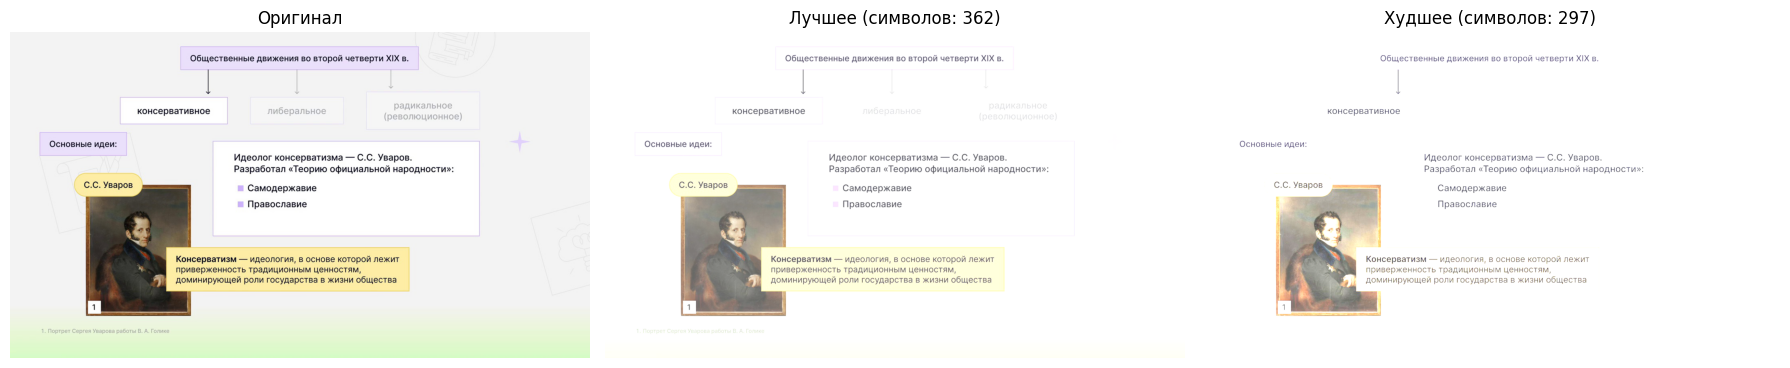

"Лучший текст (символов: 362) α: 0.80, β: 88","Худший текст (символов: 297) α: 1.57, β: 76"
"Общественные движения во второй четверти ХИХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: —__ _ С.С. Уваров о Самодержавие Православие Консерватизм — идеология, в основе которой лежит приверженность традиционным ценностям, доминирующей роли государства в жизни общества","Общественные движения во второй четверти ХИХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: С.С. Уваров Самодержавие Православие Консерватизм — идеология, в основе которой лежит приверженность традиционным ценностям,"


  0:01:38.893  ₀⡄₂₇⡄₅₄.₄₃₀ keyframe_04.jpg обработан

🔎 Обработка: keyframe_08.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
449 449 449 449 449 449 449 443 443 444 444 444 442 445 460 460 460 459 451 449 449 454 448 457 alpha=0.80
449 443 443 444 444 444 442 445 445 460 460 460 459 451 457 449 453 454 448 458 460 450 441 455 alpha=0.87
444 442 445 445 460 460 445 460 451 457 449 456 453 454 459 459 461 451 441 451 458 439 438 437 alpha=0.94
460 445 460 459 451 457 449 456 453 448 457 460 461 450 441 454 452 449 439 438 435 437 430 430 alpha=1.01
457 449 456 456 456 449 460 460 449 448 441 454 452 457 440 438 437 437 435 430 430 432 432 432 alpha=1.08
454 458 460 460 451 450 450 454 452 449 448 439 437 435 435 435 430 430 432 432 432 430 414 414 alpha=1.15
461 450 441 451 452 458 439 440 439 436 437 435 430 430 430 432 430 432 430

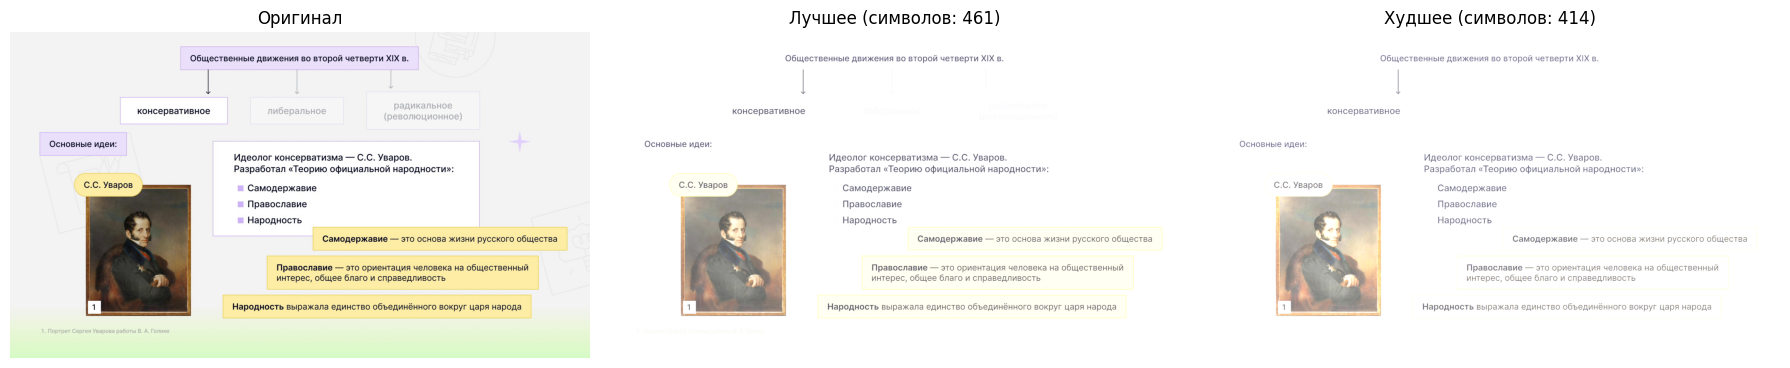

"Лучший текст (символов: 461) α: 0.94, β: 88","Худший текст (символов: 414) α: 1.15, β: 106"
"Общественные движения во второй четверти ХИХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: _ С.С. Уваров Самодержавие Православие Народность | Самодержавие — это основа жизни русского общества | Православие — это ориентация человека на общественный интерес, общее благо и справедливость | Народность выражала единство объединённого вокруг царя народа | |","Общественные движения во второй четверти ХХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: Самодержавие Православие Народность Самодержавие — это основа жизни русского общества Православие — это ориентация человека на общественный интерес, общее благо и справедливость Народность выражала единство объединённого вокруг царя народа"


  0:02:26.310  ₀⡄₃₀⡄₂₀.₇₄₁ keyframe_08.jpg обработан

🔎 Обработка: keyframe_10.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
178 178 178 178 178 178 178 178 183 183 178 183 183 183 183 188 188 192 194 192 181 178 181 189 alpha=0.80
178 178 183 183 178 178 183 183 178 183 188 188 192 194 183 192 178 180 180 189 187 182 191 184 alpha=0.87
183 183 183 178 183 188 188 191 194 183 192 177 178 180 180 188 187 189 190 184 185 186 186 185 alpha=0.94
188 188 190 192 183 183 179 181 180 180 188 188 192 189 191 184 186 187 187 185 186 182 183 184 alpha=1.01
183 192 181 178 180 180 190 187 192 183 191 184 184 184 187 186 187 184 183 183 183 183 180 180 alpha=1.08
180 180 188 188 189 183 192 192 187 185 187 187 185 184 182 183 183 183 180 180 183 182 163 163 alpha=1.15
192 183 192 184 184 185 187 187 187 186 183 182 183 184 183 180 180 183 182

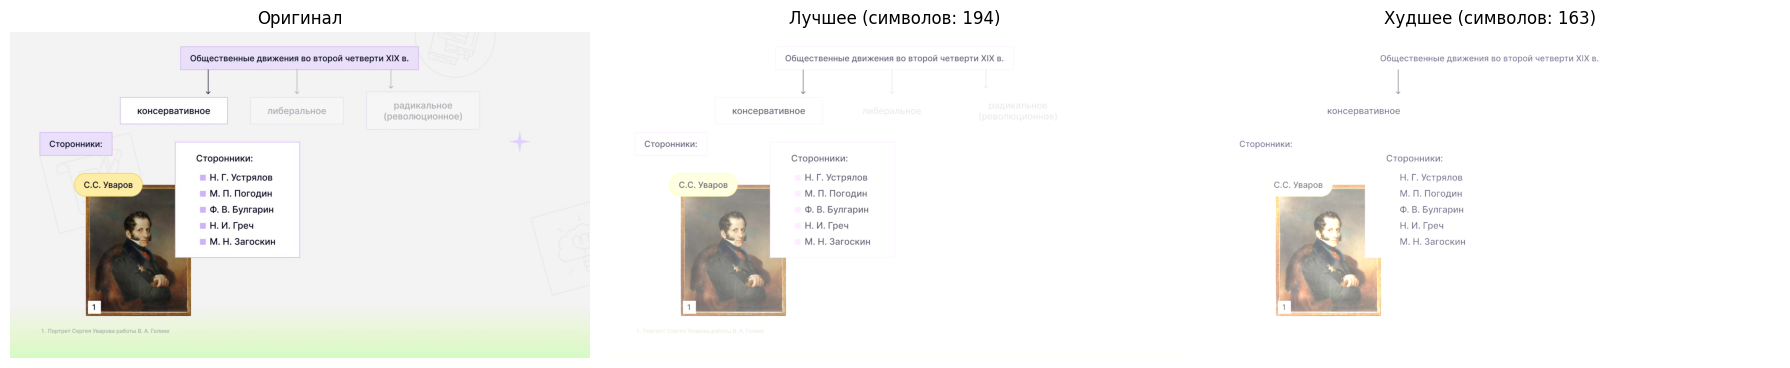

"Лучший текст (символов: 194) α: 0.80, β: 94","Худший текст (символов: 163) α: 1.15, β: 106"
Общественные движения во второй четверти ХИХ в. | консервативное Сторонники: Сторонники: Н. Г. Устрялов С.С. Уваров М. П. Погодин Ф. В. Булгарин Н. И. Греч М. Н. Загоскин № _,Общественные движения во второй четверти ХХ в. | консервативное Сторонники: Сторонники: Н. Г. Устрялов М. П. Погодин Ф. В. Булгарин Н. И. Греч М. Н. Загоскин


  0:01:36.587  ₀⡄₃₁⡄₅₇.₃₂₈ keyframe_10.jpg обработан

🔎 Обработка: keyframe_11.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
221 221 221 221 221 221 221 221 227 221 221 221 221 221 221 232 232 232 232 230 221 221 223 231 alpha=0.80
221 221 227 227 221 221 221 221 221 221 232 232 232 232 225 230 221 223 228 232 230 227 234 234 alpha=0.87
221 221 221 221 221 232 232 221 232 225 230 221 221 223 228 232 230 227 235 234 239 231 228 229 alpha=0.94
221 232 221 232 232 225 230 221 221 223 228 232 228 227 234 234 239 239 229 228 226 226 224 224 alpha=1.01
225 230 221 221 223 223 232 233 228 234 234 234 237 238 232 228 229 226 224 224 224 224 224 224 alpha=1.08
223 228 232 230 228 234 235 234 233 239 231 229 229 226 224 224 224 224 224 224 227 227 224 207 alpha=1.15
228 227 234 234 234 238 231 229 229 226 227 224 224 224 224 224 224 227 227

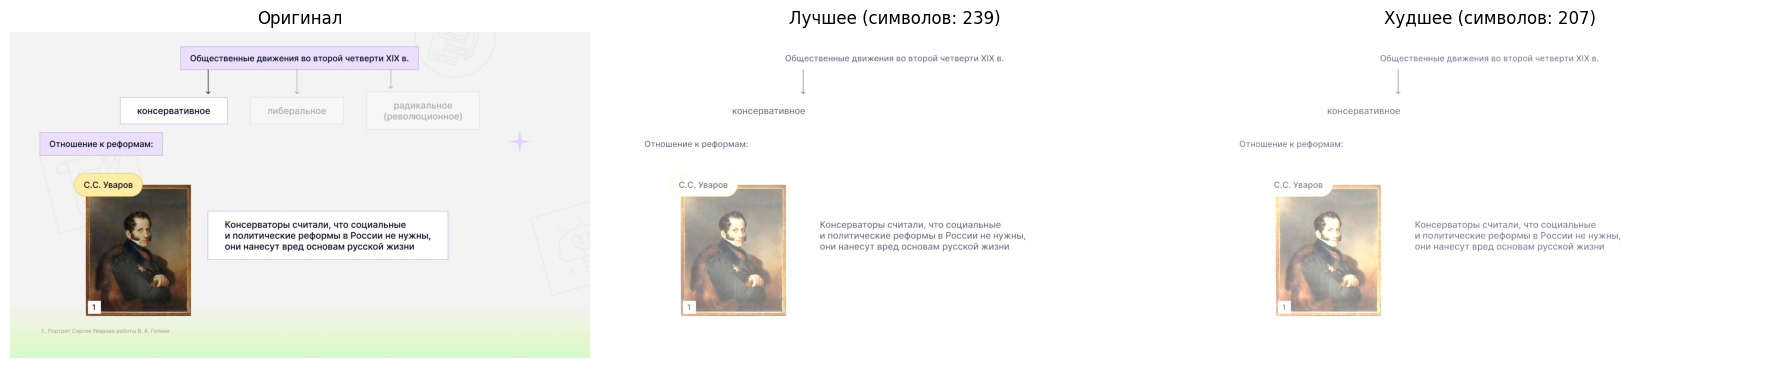

"Лучший текст (символов: 239) α: 0.94, β: 100","Худший текст (символов: 207) α: 1.15, β: 109"
"Общественные движения во второй четверти ХИХ в. | консервативное Отношение к реформам: ( С.С. Уваров . вх Консерваторы считали, что социальные и политические реформы в России не нужны, они нанесут вред основам русской жизни","Общественные движения во второй четверти ХХ в. | консервативное Отношение к реформам: Консерваторы считали, что социальные и политические реформы в России не нужны, они нанесут вред основам русской Жизни"


  0:01:47.888  ₀⡄₃₃⡄₄₅.₂₁₆ keyframe_11.jpg обработан

🔎 Обработка: keyframe_12.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
109 109 109 109 109 109 109 109 109 133 126 136 121 109 245 245 245 245 245 242 242 242 242 239 alpha=0.80
111 109 109 109 130 124 136 109 109 245 245 245 245 245 245 242 242 242 239 239 239 239 239 238 alpha=0.87
124 121 109 109 245 245 245 245 245 245 242 242 242 242 239 239 239 239 239 239 239 235 235 235 alpha=0.94
245 245 245 245 245 245 242 242 242 242 239 239 239 239 239 239 239 236 236 236 235 235 236 236 alpha=1.01
245 242 242 242 242 239 239 239 239 239 239 239 239 236 236 236 235 236 235 235 235 236 235 235 alpha=1.08
242 239 239 239 239 239 239 239 239 237 236 236 235 235 235 235 235 236 235 235 235 235 235 236 alpha=1.15
239 239 239 239 239 237 236 236 235 236 236 235 235 235 235 235 235 236 235

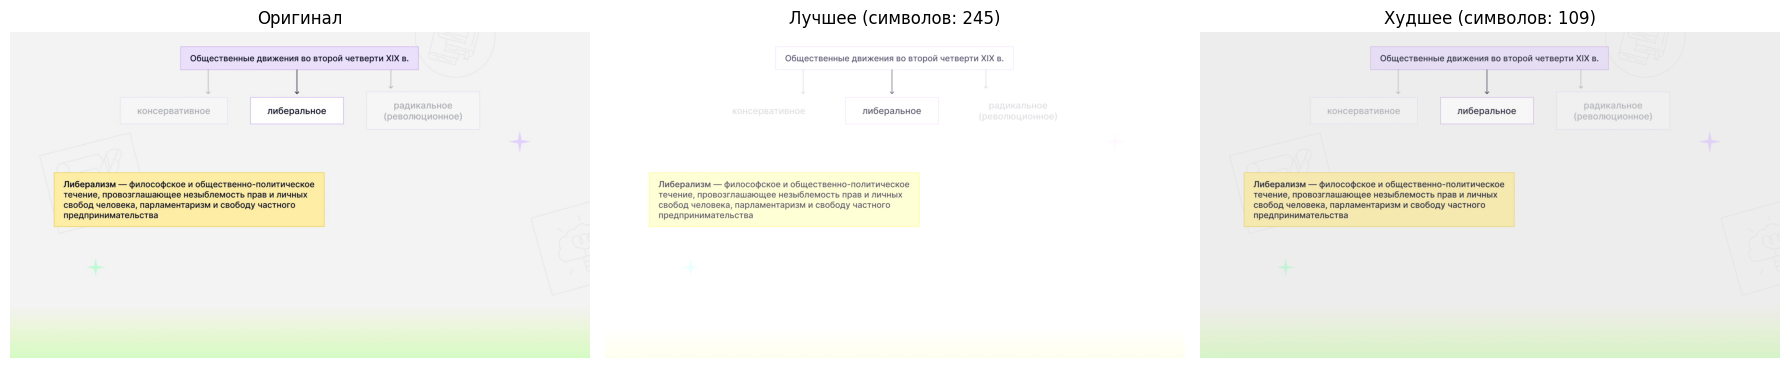

"Лучший текст (символов: 245) α: 0.80, β: 82","Худший текст (символов: 109) α: 0.80, β: 43"
"Общественные движения во второй четверти ХИХ в. | либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства",Общественные движения во второй четверти ХИХ в. | | радикальное консервативное либеральное (революционное)


  0:01:39.693  ₀⡄₃₅⡄₂₄.₉₁₀ keyframe_12.jpg обработан

🔎 Обработка: keyframe_14.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
246 246 244 244 246 244 244 233 233 246 251 252 379 379 379 379 379 379 379 376 376 376 373 367 alpha=0.80
233 233 233 246 248 239 379 379 379 379 379 379 379 379 379 376 376 373 367 367 367 367 367 366 alpha=0.87
251 379 379 379 379 379 379 379 379 379 376 376 376 373 367 367 367 367 367 367 367 368 366 366 alpha=0.94
379 379 379 379 379 379 376 376 373 373 367 367 367 367 367 367 367 369 367 367 366 366 367 367 alpha=1.01
379 376 376 376 373 367 367 367 367 367 367 367 367 369 367 367 366 367 366 366 366 367 366 366 alpha=1.08
373 367 367 367 367 367 367 367 367 366 367 367 366 366 366 366 366 367 366 366 366 366 366 367 alpha=1.15
367 367 367 367 367 366 367 367 366 367 367 366 366 366 366 366 366 367 366

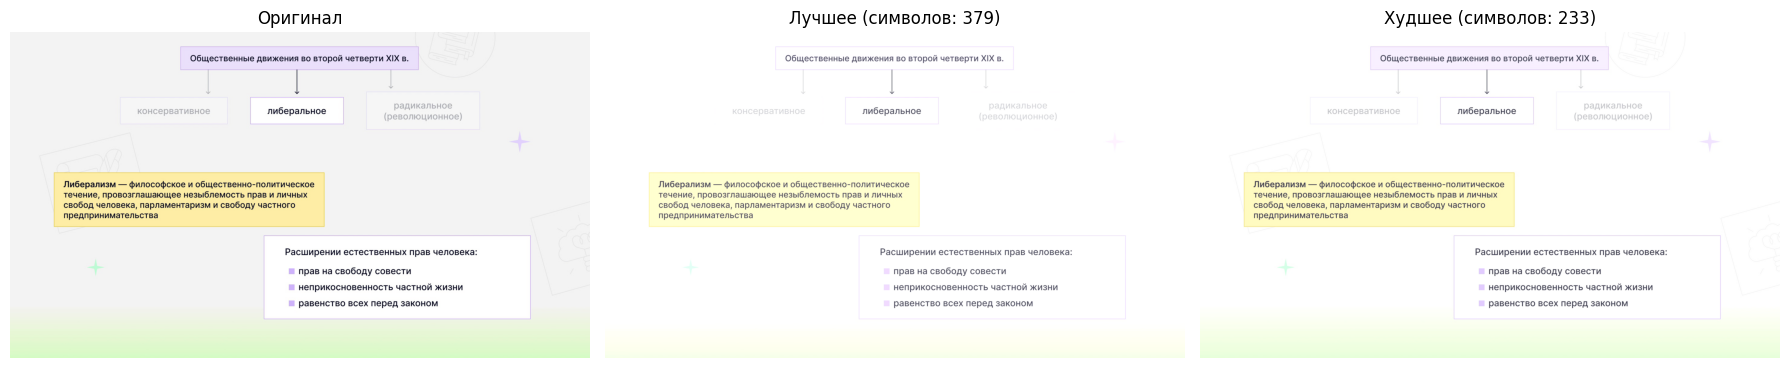

"Лучший текст (символов: 379) α: 0.80, β: 76","Худший текст (символов: 233) α: 0.80, β: 61"
"Общественные движения во второй четверти ХИХ в. | либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства Расширении естественных прав человека: прав на свободу совести неприкосновенность частной жизни равенство всех перед законом",Общественные движения во второй четверти ХИХ в. радикальное (революционное) консервативное либеральное Расширении естественных прав человека: прав на свободу совести неприкосновенность частной жизни равенство всех перед законом


  0:02:06.419  ₀⡄₃₇⡄₃₁.₃₂₉ keyframe_14.jpg обработан

🔎 Обработка: keyframe_16.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
199 199 199 199 198 198 198 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 alpha=0.80
199 198 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 alpha=0.87
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 198 198 alpha=0.94
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 198 199 199 alpha=1.01
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 199 198 198 198 199 198 198 alpha=1.08
199 199 199 199 199 199 199 199 199 198 199 199 198 198 198 198 198 199 198 198 198 198 198 199 alpha=1.15
199 199 199 199 199 198 199 199 198 199 199 198 198 198 198 198 198 199 198

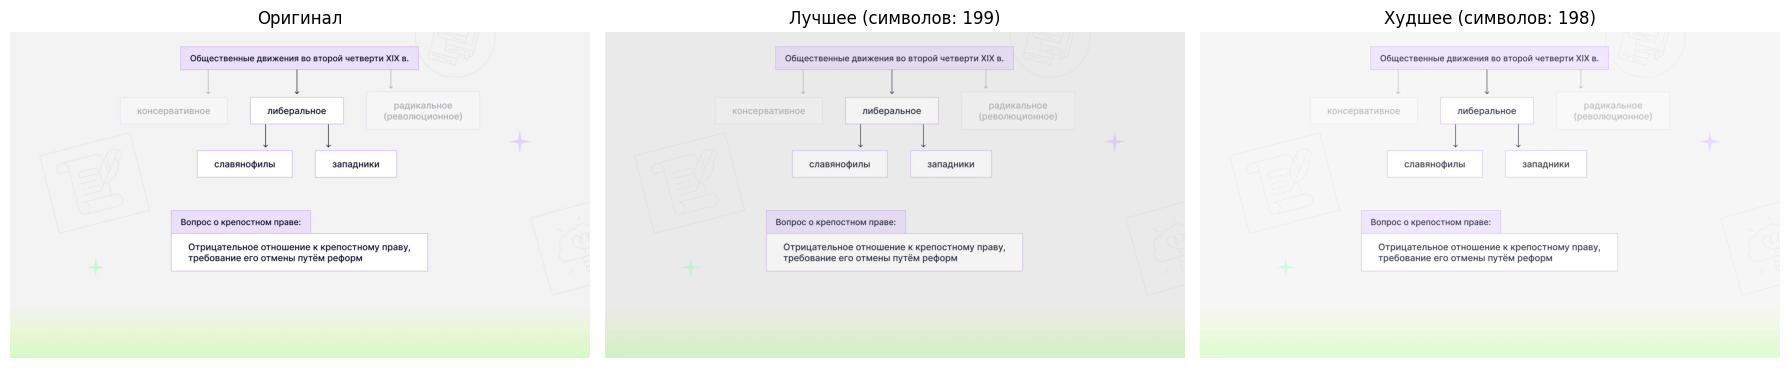

"Лучший текст (символов: 199) α: 0.80, β: 40","Худший текст (символов: 198) α: 0.80, β: 52"
"Общественные движения во второй четверти ХИХ в. | либеральное ""И славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ","Общественные движения во второй четверти ХИХ в. | либеральное И славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ"


  0:01:33.872  ₀⡄₃₉⡄₀₅.₂₀₁ keyframe_16.jpg обработан

🔎 Обработка: keyframe_17.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
199 199 199 199 198 198 198 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 alpha=0.80
199 198 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 alpha=0.87
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 198 198 alpha=0.94
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 198 199 199 alpha=1.01
199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 199 198 199 198 198 198 199 198 198 alpha=1.08
199 199 199 199 199 199 199 199 199 198 199 199 198 198 198 198 198 199 198 198 198 198 198 199 alpha=1.15
199 199 199 199 199 198 199 199 198 199 199 198 198 198 198 198 198 199 198

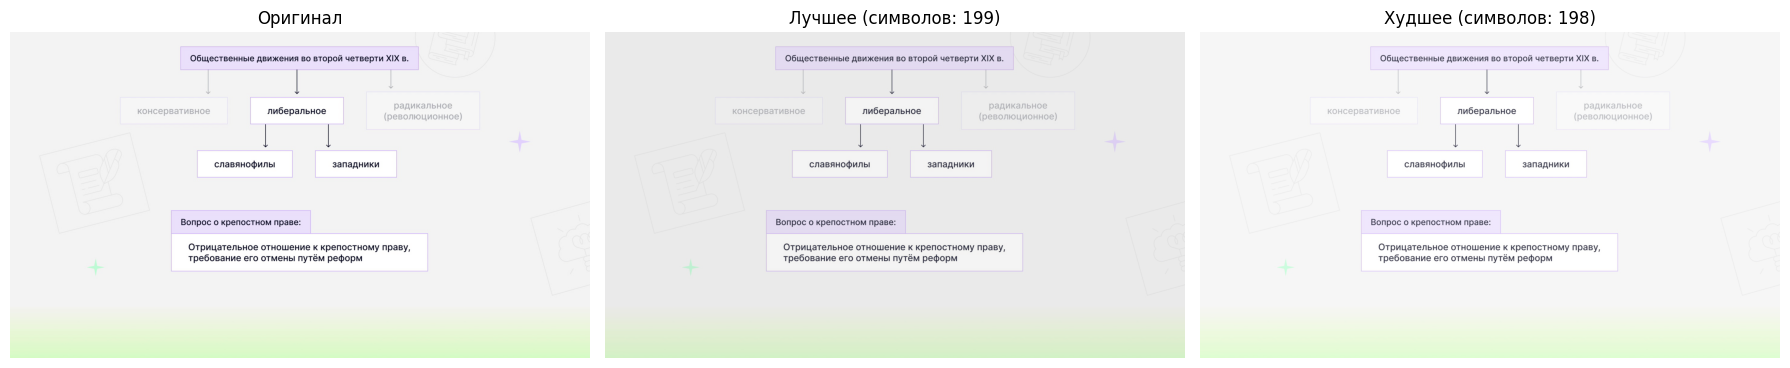

"Лучший текст (символов: 199) α: 0.80, β: 40","Худший текст (символов: 198) α: 0.80, β: 52"
"Общественные движения во второй четверти ХИХ в. | либеральное ""И славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ","Общественные движения во второй четверти ХИХ в. | либеральное И славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ"


  0:01:34.270  ₀⡄₄₀⡄₃₉.₄₇₂ keyframe_17.jpg обработан

🔎 Обработка: keyframe_18.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
138 138 138 138 138 138 138 136 136 130 154 145 136 138 288 288 288 288 288 288 285 285 282 282 alpha=0.80
140 138 136 136 130 154 145 138 136 288 288 288 288 288 285 285 285 285 282 282 282 282 282 281 alpha=0.87
145 138 136 138 288 288 288 288 288 288 285 285 285 282 282 282 286 282 282 282 282 281 281 281 alpha=0.94
288 288 288 288 288 285 285 285 285 282 282 282 286 282 282 282 282 282 282 282 281 281 282 279 alpha=1.01
288 285 285 285 282 282 282 282 286 282 282 282 282 282 282 282 281 281 281 278 278 279 278 278 alpha=1.08
282 282 282 282 286 282 282 282 282 281 282 282 281 281 281 281 278 279 278 278 278 278 278 279 alpha=1.15
282 282 282 282 282 281 282 282 281 282 281 281 281 278 278 278 278 279 278

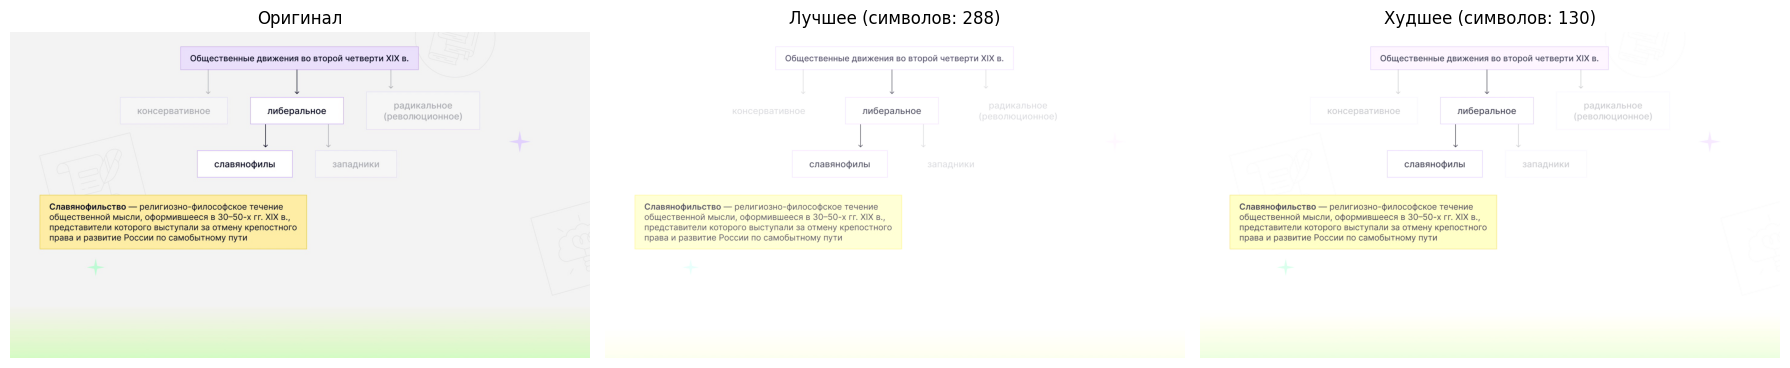

"Лучший текст (символов: 288) α: 0.80, β: 82","Худший текст (символов: 130) α: 0.80, β: 67"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути",Общественные движения во второй четверти ХИХ в. консервативное либеральное [| славянофилы западники радикальное (революционное)


  0:01:50.454  ₀⡄₄₂⡄₂₉.₉₂₆ keyframe_18.jpg обработан

🔎 Обработка: keyframe_20.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
232 232 232 232 232 232 235 233 208 210 214 224 365 365 365 365 365 365 365 362 362 359 359 356 alpha=0.80
232 210 208 208 210 224 224 365 365 365 365 365 365 365 362 362 362 359 359 356 356 357 356 356 alpha=0.87
224 214 365 365 365 365 365 365 365 365 362 362 362 359 359 356 360 357 357 356 357 357 356 356 alpha=0.94
365 365 365 365 365 362 362 362 359 359 359 356 360 357 356 357 357 356 357 357 356 356 356 356 alpha=1.01
365 362 362 362 359 359 356 356 360 357 356 357 357 357 357 357 356 356 356 357 356 356 356 356 alpha=1.08
359 359 356 356 361 357 357 356 357 357 356 356 356 356 356 356 356 357 356 356 356 356 355 355 alpha=1.15
357 356 356 357 357 357 357 356 356 357 356 356 356 357 357 356 356 356 357

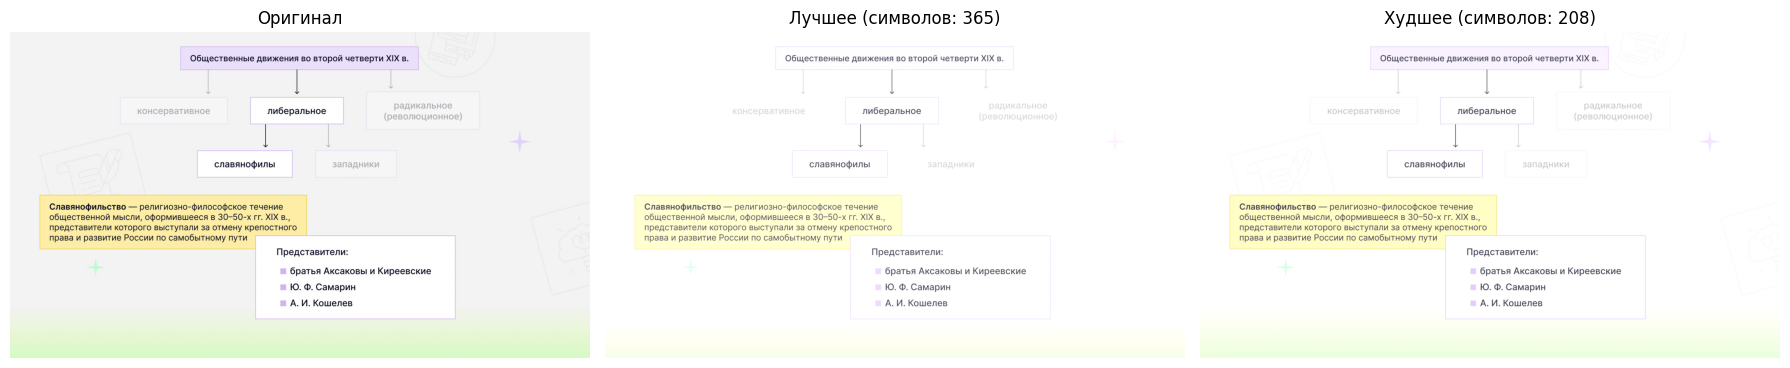

"Лучший текст (символов: 365) α: 0.80, β: 76","Худший текст (символов: 208) α: 0.80, β: 64"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути Представители: братья Аксаковы и Киреевские Ю. Ф. Самарин А. И. Кошелев",Общественные движения во второй четверти ХИХ в. консервативное либеральное [| славянофилы западники радикальное (революционное) Представители: братья Аксаковы и Киреевские Ю. Ф. Самарин А. И. Кошелев


  0:02:01.295  ₀⡄₄₄⡄₃₁.₂₂₁ keyframe_20.jpg обработан

🔎 Обработка: keyframe_21.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
111 111 111 111 111 111 111 111 284 283 283 283 283 283 283 285 285 285 285 288 288 288 316 317 alpha=0.80
114 111 283 284 283 283 283 283 283 283 285 285 285 288 288 288 288 316 308 317 315 312 312 320 alpha=0.87
283 283 283 283 283 285 285 285 285 288 288 288 288 288 316 314 315 312 312 320 319 308 303 302 alpha=0.94
285 285 285 285 288 288 288 288 288 316 316 314 315 312 312 320 319 313 308 302 302 303 302 302 alpha=1.01
288 288 288 288 316 308 317 315 315 312 312 320 319 308 307 303 301 302 302 302 302 302 302 302 alpha=1.08
308 308 317 315 312 312 312 320 319 315 307 312 302 300 302 302 302 302 302 302 302 302 302 299 alpha=1.15
312 312 312 320 319 315 308 311 300 300 300 302 302 302 302 302 302 302 302

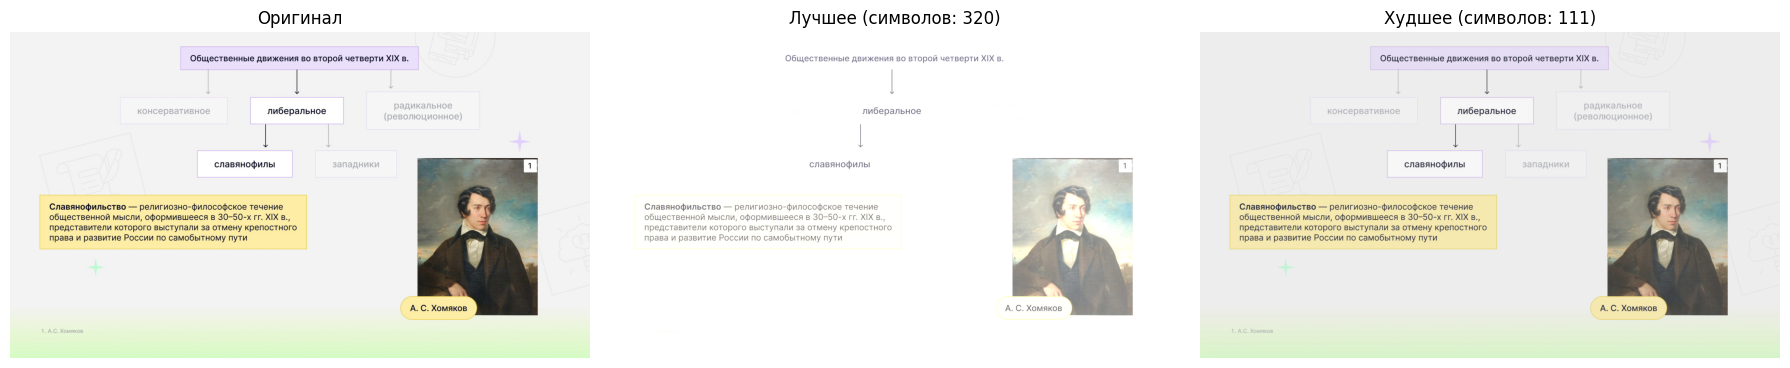

"Лучший текст (символов: 320) α: 0.87, β: 109","Худший текст (символов: 111) α: 0.80, β: 43"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути А. С. Хомяков - ро м",Общественные движения во второй четверти ХИХ в. | | либеральное | славянофилы 1. А.С. Хомяков


  0:02:04.648  ₀⡄₄₆⡄₃₅.₈₆₉ keyframe_21.jpg обработан

🔎 Обработка: keyframe_22.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
411 411 411 411 411 411 429 429 426 428 428 428 428 428 428 426 428 428 428 426 426 426 426 433 alpha=0.80
429 429 426 426 428 428 428 428 428 428 426 428 428 426 428 426 426 433 433 433 435 434 434 441 alpha=0.87
428 428 428 428 428 426 428 428 426 428 426 426 426 426 433 431 437 434 434 435 436 434 432 431 alpha=0.94
426 428 428 428 426 426 426 426 426 426 433 430 437 434 434 435 437 441 432 431 431 432 431 431 alpha=1.01
428 426 426 426 433 433 433 430 435 433 433 435 437 442 434 432 432 431 431 431 431 431 431 431 alpha=1.08
426 433 433 431 431 433 434 441 441 441 435 430 431 431 431 431 431 431 431 431 431 431 432 432 alpha=1.15
431 433 434 436 440 441 441 429 431 431 431 431 431 431 431 431 431 431 431

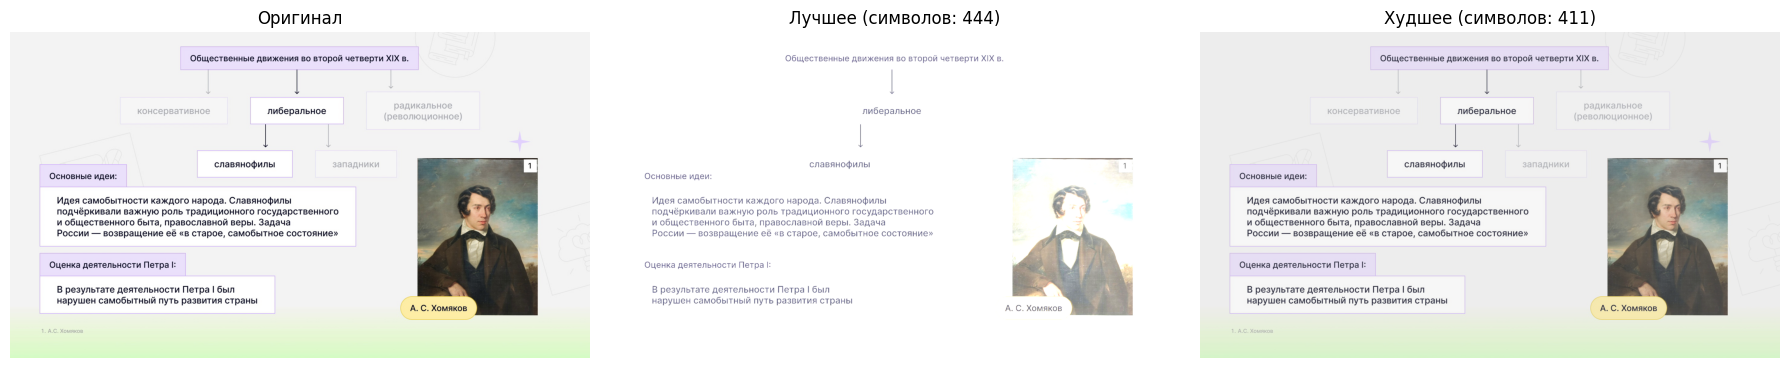

"Лучший текст (символов: 444) α: 1.57, β: 94","Худший текст (символов: 411) α: 0.80, β: 43"
"Общественные движения во второй четверти Х\Х в. | либеральное | славянофилы ее 1 Основные идеи: Идея самобытности каждого народа. Славянофилы — подчёркивали важную роль традиционного государственного и общественного быта, православной веры. Задача России — возвращение её «в старое, самобытное состояние» = Оценка деятельности Петра |: В результате деятельности Петра | был ` нарушен самобытный путь развития страны А. С. Хомяков","Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Основные идеи: Идея самобытности каждого народа. Славянофилы подчёркивали важную роль традиционного государственного и общественного быта, православной веры. Задача России — возвращение её «в старое, самобытное состояние» Оценка деятельности Петра 1: В результате деятельности Петра | был нарушен самобытный путь развития страны"


  0:02:26.972  ₀⡄₄₉⡄₀₂.₈₄₂ keyframe_22.jpg обработан

🔎 Обработка: keyframe_23.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
298 298 298 298 298 312 312 298 313 313 315 315 315 315 313 313 313 315 313 313 313 313 320 313 alpha=0.80
312 298 298 313 313 315 315 315 315 313 313 313 315 313 315 313 313 313 313 313 317 318 321 331 alpha=0.87
315 315 315 315 315 313 315 315 315 313 315 313 313 313 320 320 319 318 321 331 324 325 322 318 alpha=0.94
315 313 315 315 313 315 313 313 313 320 320 320 319 318 321 331 325 325 326 318 318 319 318 318 alpha=1.01
315 315 313 313 313 313 313 317 317 323 320 331 326 329 325 319 319 318 318 318 318 318 318 318 alpha=1.08
320 313 320 320 323 318 321 331 325 327 326 322 318 318 318 318 318 318 318 318 318 318 318 319 alpha=1.15
323 321 321 332 324 327 328 321 318 318 318 318 318 318 318 318 318 318 318

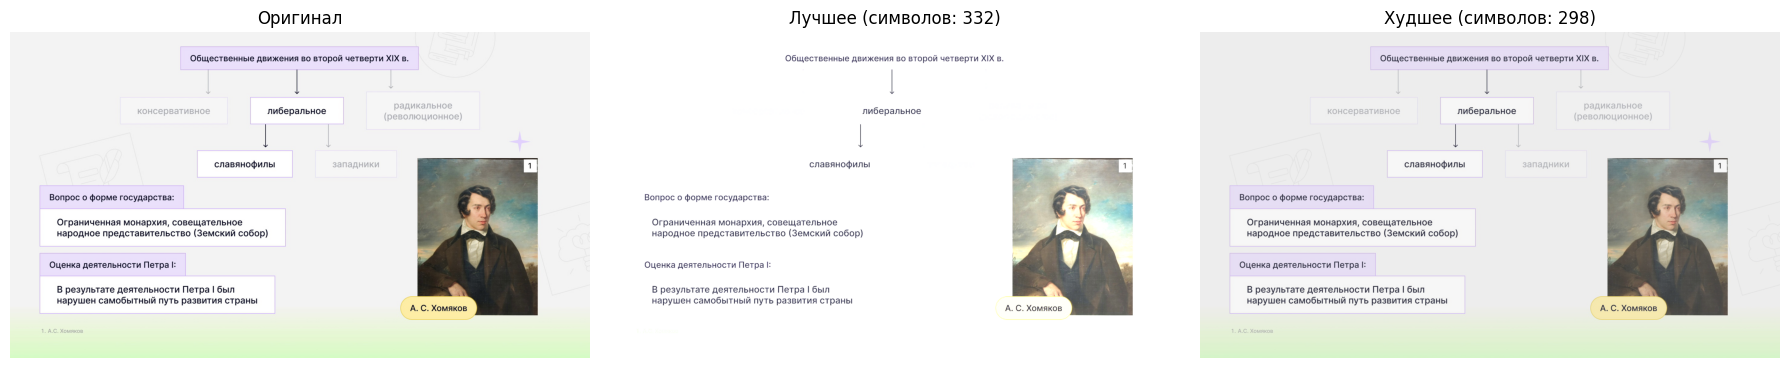

"Лучший текст (символов: 332) α: 1.22, β: 49","Худший текст (символов: 298) α: 0.80, β: 43"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор) Оценка деятельности Петра 1: В результате деятельности Петра | был нарушен самобытный путь развития страны ра _ А. С. Хомяков м < ря","Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор) Оценка деятельности Петра 1: В результате деятельности Петра | был нарушен самобытный путь развития страны"


  0:02:06.679  ₀⡄₅₁⡄₀₉.₅₂₂ keyframe_23.jpg обработан

🔎 Обработка: keyframe_24.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
298 298 298 298 298 312 312 298 313 313 315 315 315 315 313 313 313 315 313 313 313 313 320 313 alpha=0.80
312 298 316 313 313 315 315 315 315 313 313 313 315 313 315 313 313 313 313 313 317 318 321 331 alpha=0.87
315 315 315 315 315 313 315 315 315 313 315 313 313 313 320 320 319 318 321 331 324 325 322 318 alpha=0.94
315 313 315 315 313 315 313 313 313 320 320 320 319 318 321 331 325 325 326 318 318 319 318 318 alpha=1.01
315 315 313 313 313 313 313 317 317 323 320 331 326 329 325 319 319 318 318 318 318 318 318 318 alpha=1.08
320 313 320 320 323 318 321 331 325 327 326 322 318 318 318 318 318 318 318 318 318 318 318 319 alpha=1.15
323 321 321 332 324 327 328 321 318 318 318 318 318 318 318 318 318 318 318

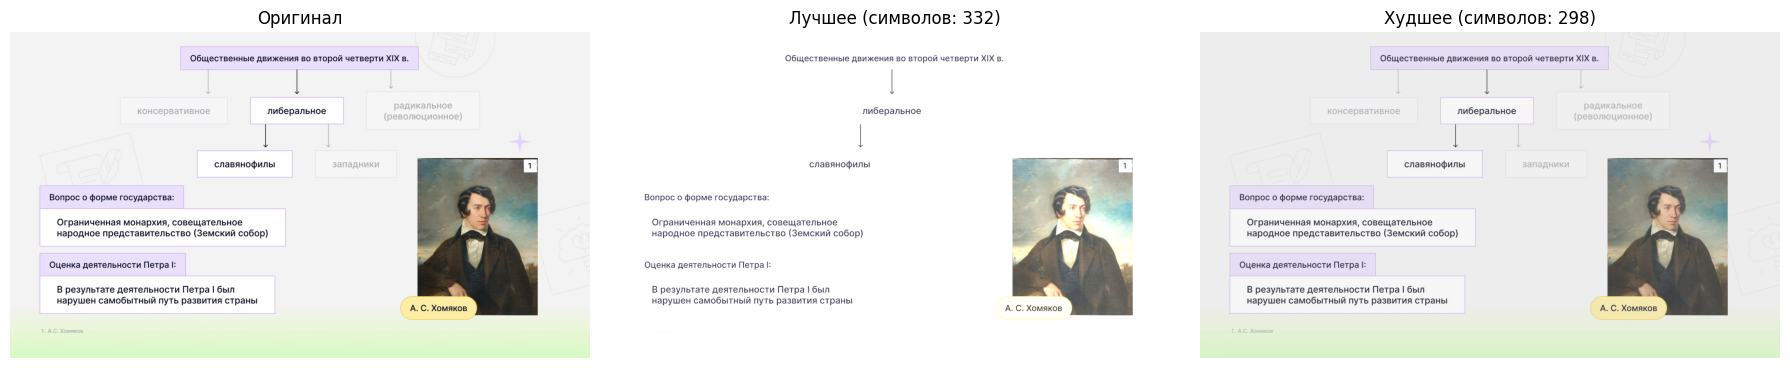

"Лучший текст (символов: 332) α: 1.22, β: 49","Худший текст (символов: 298) α: 0.80, β: 43"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор) Оценка деятельности Петра 1: В результате деятельности Петра | был нарушен самобытный путь развития страны ра _ А. С. Хомяков м < ря","Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор) Оценка деятельности Петра 1: В результате деятельности Петра | был нарушен самобытный путь развития страны"


  0:02:04.648  ₀⡄₅₃⡄₁₄.₁₇₀ keyframe_24.jpg обработан

🔎 Обработка: keyframe_25.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
251 251 251 251 251 251 251 251 245 266 259 262 442 442 442 442 442 442 442 442 436 436 436 430 alpha=0.80
253 251 245 245 259 265 290 442 442 442 442 442 442 442 442 436 436 436 433 430 430 430 430 429 alpha=0.87
290 262 442 442 442 442 442 442 442 442 442 436 436 436 433 430 430 430 430 430 430 429 429 429 alpha=0.94
442 442 442 442 442 442 436 436 436 436 433 430 430 430 430 430 430 430 430 430 429 429 430 430 alpha=1.01
442 442 436 436 436 433 430 430 430 430 430 430 430 430 430 430 429 429 429 429 429 430 429 429 alpha=1.08
436 433 430 430 430 430 430 430 430 429 430 430 429 429 429 429 429 430 429 429 429 429 429 430 alpha=1.15
430 430 430 430 430 429 430 430 429 430 429 429 429 429 429 429 429 430 429

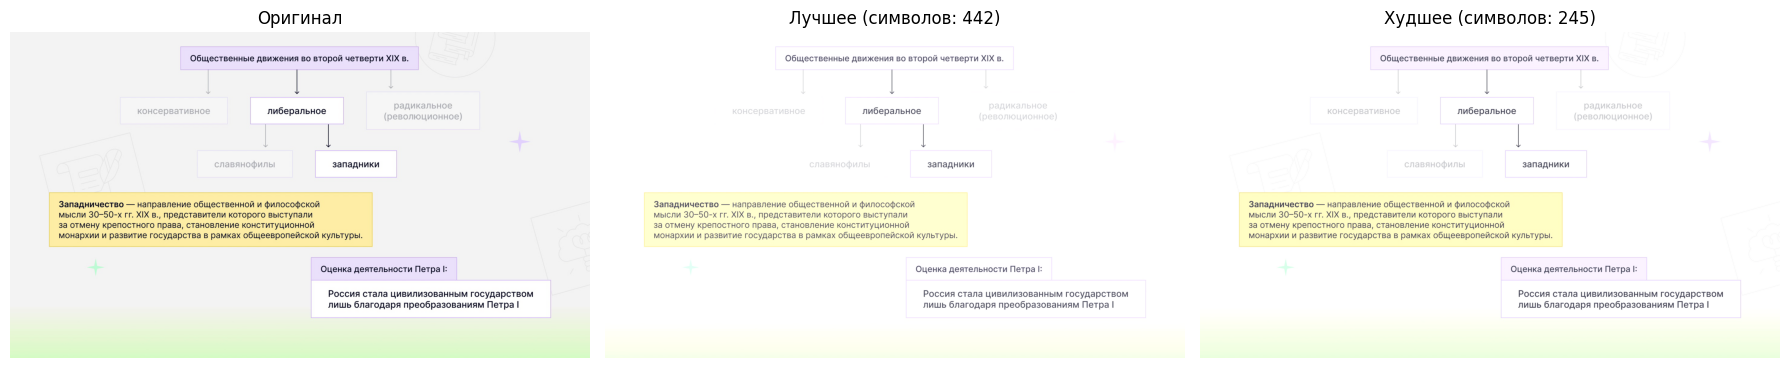

"Лучший текст (символов: 442) α: 0.80, β: 76","Худший текст (символов: 245) α: 0.80, β: 64"
"Общественные движения во второй четверти ХИХ в. | либеральное | западники Западничество — направление общественной и философской мысли 30-50-х гг. ХШХ в., представители которого выступали за отмену крепостного права, становление конституционной монархии и развитие государства в рамках общеевропейской культуры. Оценка деятельности Петра 1: Россия стала цивилизованным государством лишь благодаря преобразованиям Петра |",Общественные движения во второй четверти ХИХ в. консервативное либеральное 1 | славянофилы западники радикальное (революционное) Оценка деятельности Петра 1: Россия стала цивилизованным государством лишь благодаря преобразованиям Петра |


  0:02:13.024  ₀⡄₅₅⡄₂₇.₁₉₅ keyframe_25.jpg обработан

🔎 Обработка: keyframe_27.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 alpha=0.80
372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 371 alpha=0.87
372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 371 371 371 alpha=0.94
372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 371 371 372 372 alpha=1.01
372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 372 371 372 371 371 371 372 371 371 alpha=1.08
372 372 372 372 372 372 372 372 372 371 372 372 371 371 371 371 371 372 371 371 371 371 371 372 alpha=1.15
372 372 372 372 372 371 372 372 371 372 372 371 371 371 371 371 371 372 371

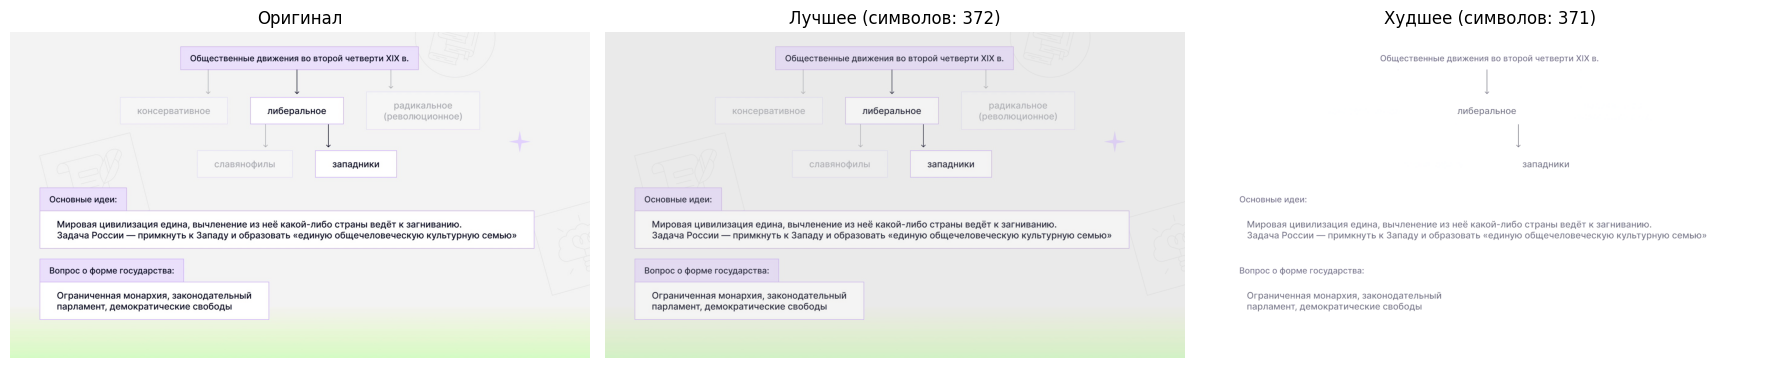

"Лучший текст (символов: 372) α: 0.80, β: 40","Худший текст (символов: 371) α: 0.87, β: 109"
"Общественные движения во второй четверти ХИХ в. | либеральное | западники Основные идеи: Мировая цивилизация едина, вычленение из неё какой-либо страны ведёт к загниванию. Задача России — примкнуть к Западу и образовать «единую общечеловеческую культурную семью» Вопрос о форме государства: Ограниченная монархия, законодательный парламент, демократические свободы","Общественные движения во второй четверти ХХ в. | либеральное | западники Основные идеи: Мировая цивилизация едина, вычленение из неё какой-либо страны ведёт к загниванию. Задача России — примкнуть к Западу и образовать «единую общечеловеческую культурную семью» Вопрос о форме государства: Ограниченная монархия, законодательный парламент, демократические свободы"


  0:02:02.810  ₀⡄₅₇⡄₃₀.₀₀₅ keyframe_27.jpg обработан

🔎 Обработка: keyframe_29.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 184 185 185 185 185 185 185 alpha=0.80
185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 alpha=0.87
185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 184 184 alpha=0.94
185 185 185 185 185 184 185 185 185 185 185 185 185 185 185 185 185 185 185 184 184 184 184 185 alpha=1.01
185 185 185 185 185 185 185 185 185 185 185 185 185 185 184 185 184 184 185 185 184 184 184 185 alpha=1.08
185 185 185 185 185 185 185 185 184 185 184 184 184 184 184 184 184 184 185 184 185 185 184 184 alpha=1.15
185 185 185 185 185 185 185 185 185 184 184 184 184 184 185 185 184 185 184

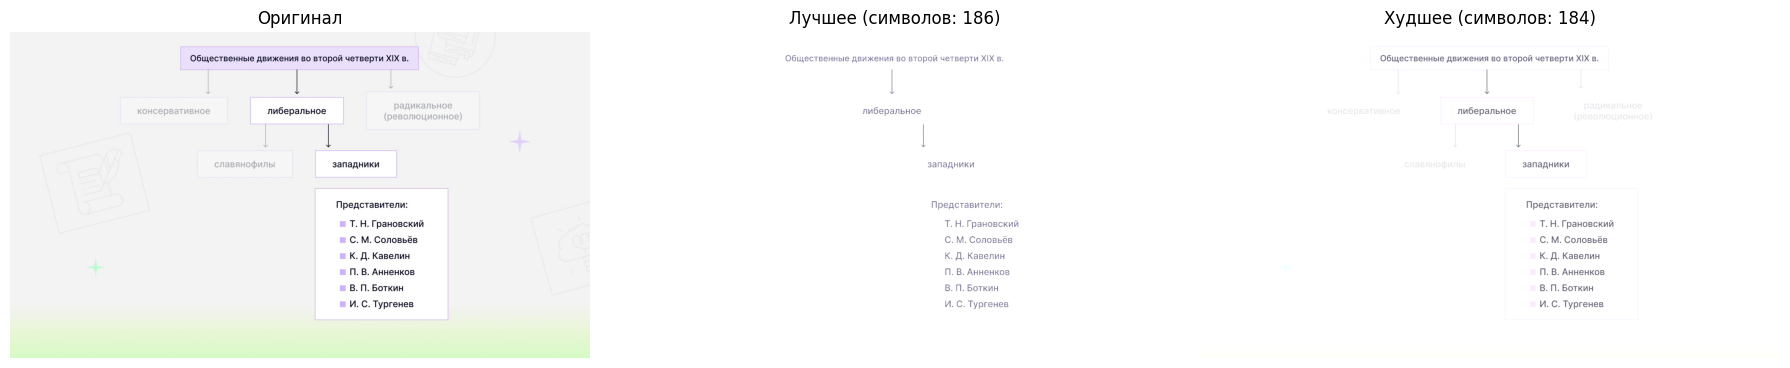

"Лучший текст (символов: 186) α: 1.36, β: 106","Худший текст (символов: 184) α: 0.80, β: 91"
Общественные движения во второй четверти ХХХ в. | либеральное | западники п редставители: Т. Н. Грановский С. М. Соловьёв К. Д. Кавелин П. В. Анненков В. П. Боткин И. С. Тургенев,Общественные движения во второй четверти ХИХ в. | либеральное | западники Представители: Т. Н. Грановский С. М. Соловьёв К. Д. Кавелин П. В. Анненков В. П. Боткин И. С. Тургенев


  0:01:29.995  ₀⡄₅₉⡄₀₀.₀₀₀ keyframe_29.jpg обработан

🔎 Обработка: keyframe_30.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
197 197 197 197 196 196 196 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 alpha=0.80
197 199 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 196 alpha=0.87
197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 196 196 196 alpha=0.94
197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 196 196 197 197 alpha=1.01
197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 197 196 197 196 196 196 197 196 196 alpha=1.08
197 197 197 197 197 197 197 197 197 196 197 197 196 196 196 196 196 197 196 196 196 196 196 200 alpha=1.15
197 197 197 197 197 196 197 197 196 197 197 196 196 196 196 196 196 197 196

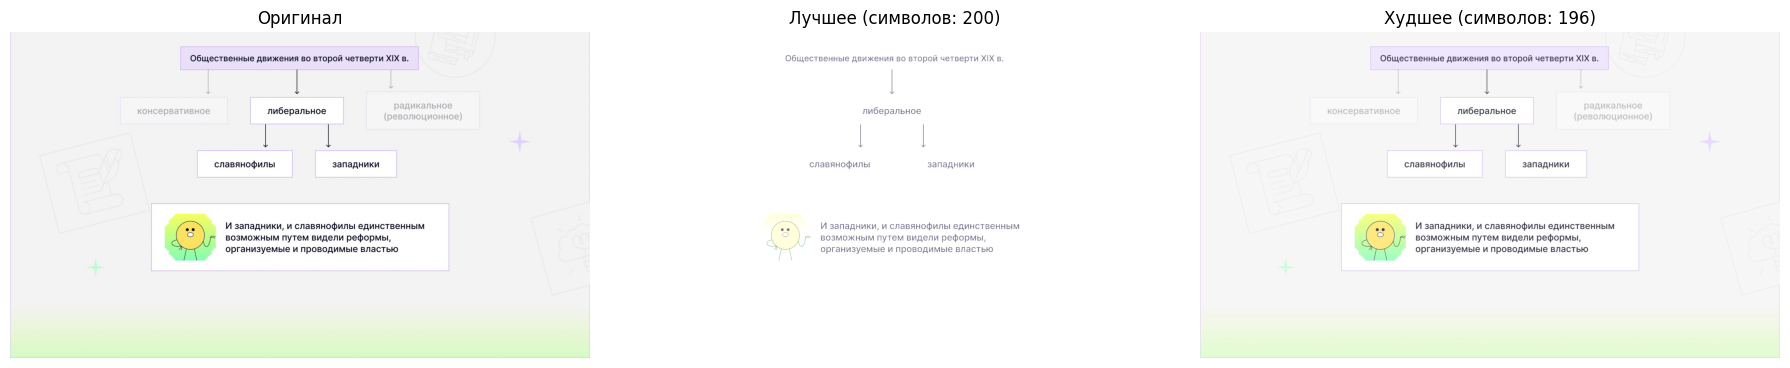

"Лучший текст (символов: 200) α: 1.15, β: 109","Худший текст (символов: 196) α: 0.80, β: 52"
"Общественные движения во второй четверти ХИХ в. | либеральное [| славянофилы западники И западники, и славянофилы единственным возможным путем видели реформы, организуемые и проводимые властью р","Общественные движения во второй четверти ХИХ в. | либеральное И славянофилы западники И западники, и славянофилы единственным возможным путем видели реформы, организуемые и проводимые властью"


  0:01:37.954  ₁⡄₀₀⡄₃₇.₉₅₄ keyframe_30.jpg обработан

🔎 Обработка: keyframe_32.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
271 271 271 271 270 270 270 271 271 271 271 271 271 271 271 274 277 277 275 274 277 271 271 252 alpha=0.80
271 270 271 271 271 271 271 271 274 271 274 277 277 275 272 274 271 271 271 252 269 278 275 272 alpha=0.87
271 271 271 274 271 274 277 277 275 272 274 252 271 271 271 252 269 277 277 275 273 272 270 270 alpha=0.94
274 277 277 275 275 271 274 252 271 271 252 269 269 279 277 273 273 273 271 271 272 251 271 270 alpha=1.01
271 274 252 252 271 271 252 269 277 277 277 273 275 273 273 271 272 251 251 271 270 270 270 270 alpha=1.08
271 271 252 269 269 278 277 273 273 272 273 271 270 272 251 271 270 270 270 270 270 270 270 271 alpha=1.15
276 277 277 273 273 272 273 271 270 273 251 251 271 270 270 270 270 271 270

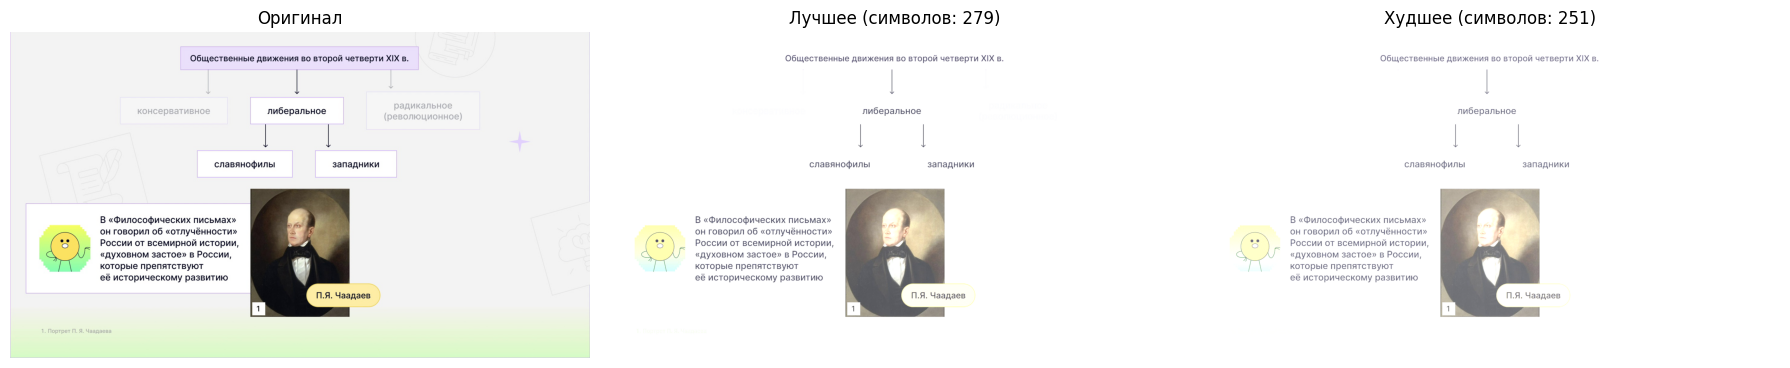

"Лучший текст (символов: 279) α: 1.01, β: 79","Худший текст (символов: 251) α: 1.01, β: 103"
"Общественные движения во второй четверти ХИХ в. | либеральное [| славянофилы западники В «Философических письмах» он говорил об «отлучённости» России от всемирной истории, «духовном застое» в России, которые препятствуют её историческому развитию < П.Я. Чаадаев | РЯ","Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники В «Философических письмах» он говорил об «отлучённости» России от всемирной истории, «духовном застое» в России, которые препятствуют её историческому развитию"


  0:02:02.075  ₁⡄₀₂⡄₄₀.₀₃₀ keyframe_32.jpg обработан

🔎 Обработка: keyframe_33.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
202 202 202 202 201 201 201 202 202 202 177 199 204 199 199 202 207 208 204 205 180 201 201 177 alpha=0.80
202 201 202 179 202 177 199 204 199 199 177 205 208 205 205 180 201 201 177 177 202 208 202 204 alpha=0.87
177 199 204 199 199 177 202 208 205 205 205 204 201 201 177 177 177 208 201 204 201 202 198 198 alpha=0.94
177 205 208 208 204 204 180 204 201 201 177 177 202 208 204 204 201 201 201 199 200 176 198 200 alpha=1.01
205 180 180 201 201 177 177 177 204 208 203 204 201 201 201 199 198 176 176 198 200 200 201 198 alpha=1.08
201 177 177 202 202 208 201 204 201 200 203 199 198 200 176 198 200 200 200 201 200 198 194 195 alpha=1.15
204 208 203 204 201 200 203 199 198 199 176 176 198 200 200 200 201 200 198

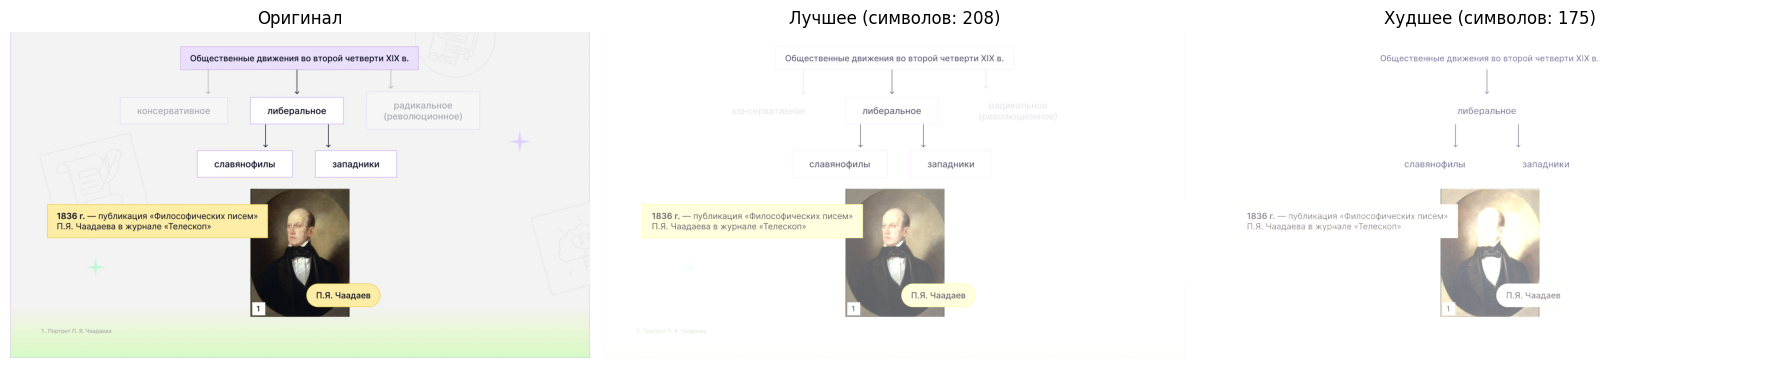

"Лучший текст (символов: 208) α: 0.80, β: 91","Худший текст (символов: 175) α: 1.50, β: 109"
Общественные движения во второй четверти ХИХ в. | либеральное [| славянофилы западники 1836 г. — публикация «Философических писем» П.Я. Чаадаева в журнале «Телескоп» {| П.Я. Чаадаев,Общественные движения во второй четверти Х\Х в. | либеральное [| славянофилы западники 1836 г. — публикация «Философических писем» П.Я. Чаадаева в журнале «Телескоп»


  0:01:44.606  ₁⡄₀₄⡄₂₄.₆₃₆ keyframe_33.jpg обработан

🔎 Обработка: keyframe_38.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
247 247 247 247 247 248 247 245 247 241 221 221 221 258 263 263 264 267 267 267 267 267 264 266 alpha=0.80
245 245 250 242 246 221 221 221 258 263 263 263 267 267 267 267 267 267 264 263 263 263 263 259 alpha=0.87
221 221 221 258 263 263 263 267 267 267 267 267 267 264 267 261 263 261 263 260 257 256 256 254 alpha=0.94
263 263 264 267 267 267 267 267 267 264 269 261 263 263 263 260 260 257 257 255 254 254 255 252 alpha=1.01
267 267 267 267 267 264 261 263 263 263 263 260 260 258 258 257 254 255 254 254 251 252 251 251 alpha=1.08
267 264 261 263 263 263 263 260 264 256 258 257 254 254 254 254 254 252 251 251 251 251 251 252 alpha=1.15
263 263 263 263 264 256 257 257 254 255 254 254 254 254 251 251 251 252 251

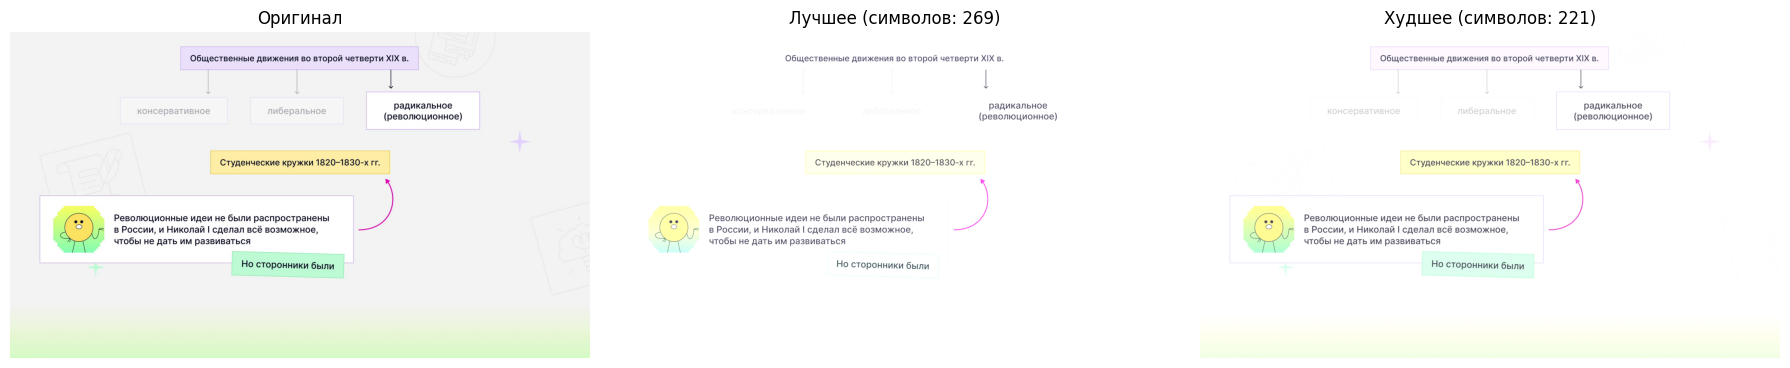

"Лучший текст (символов: 269) α: 1.01, β: 70","Худший текст (символов: 221) α: 0.80, β: 70"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) Студенческие кружки 1820-1830-х гг. | _ _ Революционные идеи не были распространены = в России, и Николай | сделал всё возможное, чтобы не дать им развиваться Но сторонники были","Общественные движения во второй четверти ХИХ в. | радикальное (революционное) Революционные идеи не были распространены в России, и Николай | сделал всё возможное, чтобы не дать им развиваться Но сторонники были"


  0:01:45.913  ₁⡄₀₆⡄₁₀.₅₅₀ keyframe_38.jpg обработан

🔎 Обработка: keyframe_40.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
171 171 171 171 171 171 171 171 171 171 171 171 171 251 251 251 251 251 251 251 251 251 248 245 alpha=0.80
171 171 171 171 171 171 171 251 251 251 251 251 251 251 251 251 251 251 248 245 245 245 245 245 alpha=0.87
171 171 251 251 251 251 251 251 251 251 251 251 251 251 248 245 245 245 245 245 245 244 245 244 alpha=0.94
251 251 251 251 251 251 251 251 251 248 248 245 245 245 245 245 245 245 245 244 244 244 244 245 alpha=1.01
251 251 251 251 251 248 245 245 245 245 245 245 245 245 244 245 245 244 244 244 244 244 244 242 alpha=1.08
251 248 245 245 245 245 245 245 245 245 245 245 244 244 244 244 245 245 244 245 245 242 242 242 alpha=1.15
245 245 245 245 245 244 245 244 244 244 244 244 245 244 244 244 244 245 241

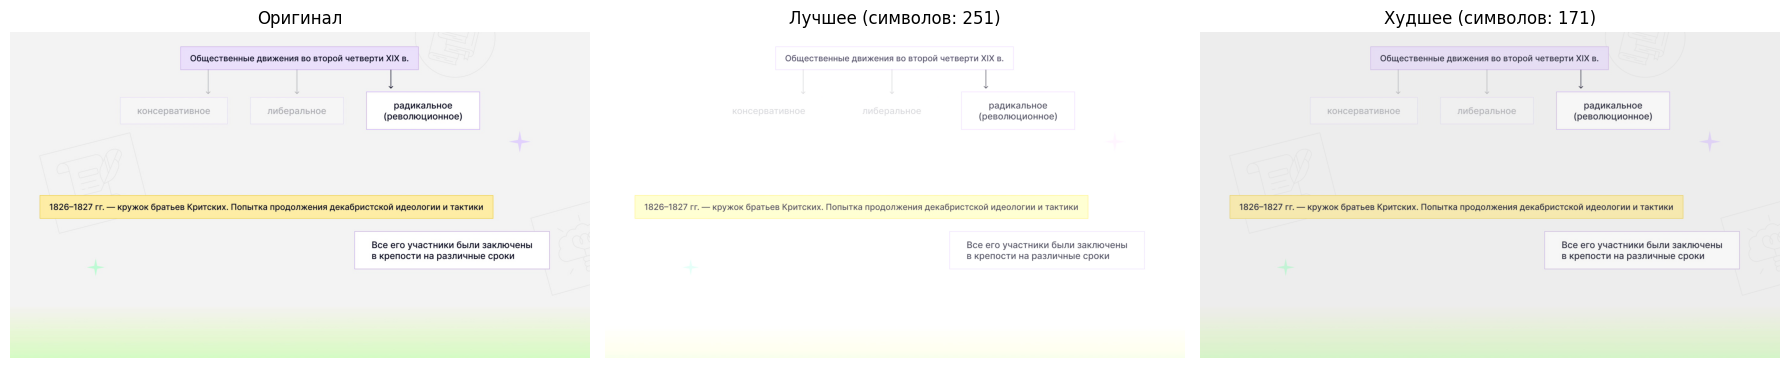

"Лучший текст (символов: 251) α: 0.80, β: 79","Худший текст (символов: 171) α: 0.80, β: 43"
Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1826-1827 гг. — кружок братьев Критских. Попытка продолжения декабристской идеологии и тактики Все его участники были заключены в крепости на различные сроки,Общественные движения во второй четверти ХИХ в. консервативное либеральное радикальное (революционное) Все его участники были заключены в крепости на различные сроки


  0:01:43.044  ₁⡄₀₇⡄₅₃.₅₉₅ keyframe_40.jpg обработан

🔎 Обработка: keyframe_43.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
329 329 329 329 329 329 329 335 323 309 425 445 442 424 389 424 424 424 430 430 430 430 430 430 alpha=0.80
332 332 335 309 425 424 445 442 424 424 424 424 424 427 430 430 430 430 430 430 430 430 432 434 alpha=0.87
445 442 442 424 430 424 424 424 427 430 430 430 430 430 430 430 430 430 433 432 442 437 446 434 alpha=0.94
424 424 424 424 427 430 430 430 430 430 430 430 430 430 433 432 432 437 446 441 430 431 432 434 alpha=1.01
430 430 430 430 430 430 430 430 430 438 433 433 432 439 445 440 434 433 430 432 433 448 433 441 alpha=1.08
430 430 430 430 430 430 434 433 432 439 441 440 433 430 433 432 434 440 447 433 439 433 434 450 alpha=1.15
430 430 433 433 433 439 437 440 433 432 433 430 432 434 434 444 436 442 433

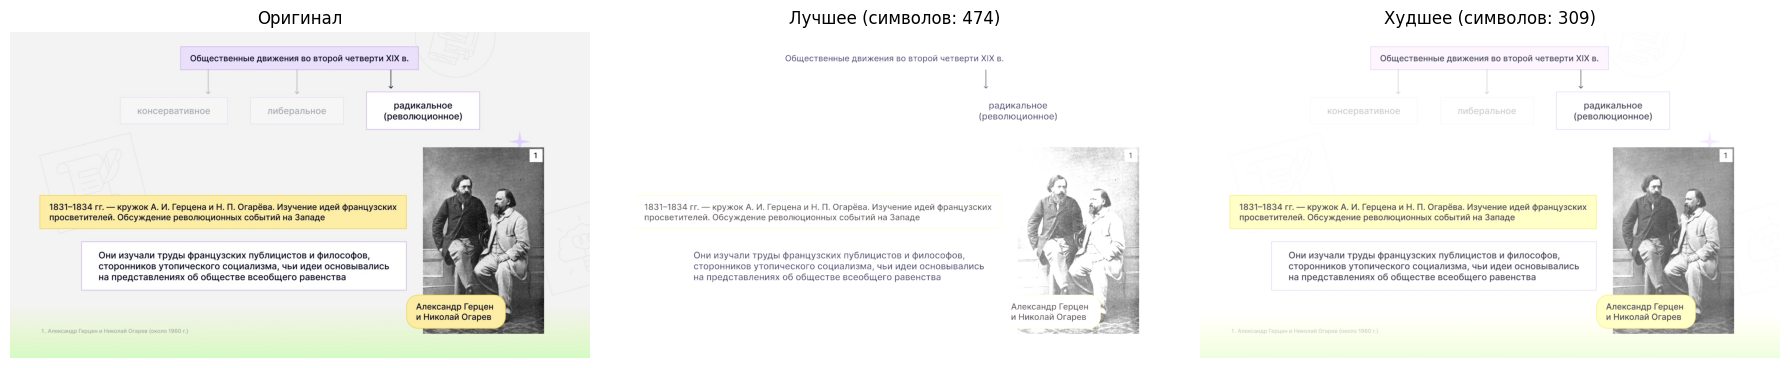

"Лучший текст (символов: 474) α: 1.50, β: 73","Худший текст (символов: 309) α: 0.80, β: 67"
"Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе ЗЕЕ ог айва Е ан Они изучали труды французских публицистов и философов, сторонников утопического социализма, чьи идеи основывались на представлениях об обществе всеобщего равенства Александр Герцен и Николай Огарев 35 ректора реки ЗЕЕЯ","Общественные движения во второй четверти ХИХ в. | радикальное (революционное) Они изучали труды французских публицистов и философов, сторонников утопического социализма, чьи идеи основывались на представлениях об обществе всеобщего равенства 1. Александр Герцен и Николай Огарев (около 1960 г.)"


  0:02:32.737  ₁⡄₁₀⡄₂₆.₃₃₂ keyframe_43.jpg обработан

🔎 Обработка: keyframe_44.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
141 141 141 141 141 141 141 141 141 143 170 245 244 221 221 224 224 224 224 224 224 224 224 224 alpha=0.80
141 141 141 141 172 243 244 245 221 221 224 224 224 224 224 224 224 224 224 224 224 224 224 224 alpha=0.87
250 244 244 245 221 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 221 221 221 221 alpha=0.94
221 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 221 220 241 220 221 220 290 alpha=1.01
224 224 224 224 224 224 224 224 224 224 224 224 224 221 220 220 221 241 220 246 252 277 243 260 alpha=1.08
224 224 224 224 224 224 224 224 224 221 220 220 220 220 220 247 278 250 244 260 265 244 249 248 alpha=1.15
224 224 224 224 223 221 221 220 240 220 243 220 220 262 275 275 275 250 243

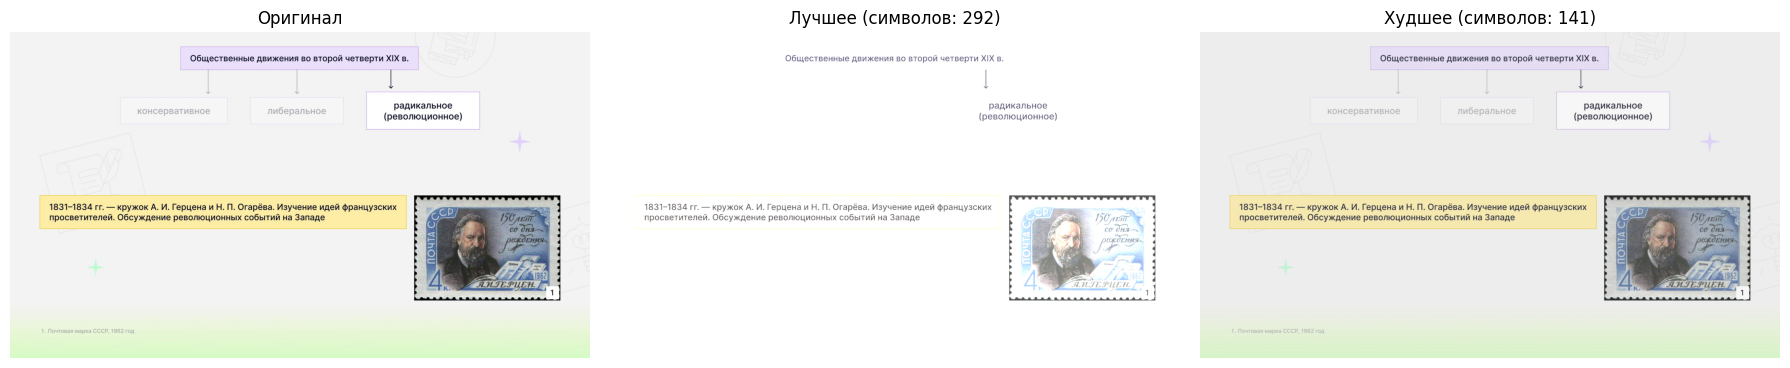

"Лучший текст (символов: 292) α: 1.29, β: 82","Худший текст (символов: 141) α: 0.80, β: 43"
"Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе РолеРА, со дня— в орет и рэ] И 48300] ЦЕН. ‹ ОИК","Общественные движения во второй четверти ХИХ в. радикальное консервативное либеральное (революционное) 1. Почтовая марка СССР, 1962 год"


  0:01:55.316  ₁⡄₁₂⡄₂₁.₆₄₉ keyframe_44.jpg обработан

🔎 Обработка: keyframe_45.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
197 197 197 197 197 197 197 192 205 192 192 198 175 308 310 299 294 299 295 315 315 315 315 319 alpha=0.80
192 192 214 192 192 194 198 175 308 294 301 294 298 295 312 315 315 315 317 319 321 305 330 275 alpha=0.87
208 198 172 308 294 299 294 294 295 312 315 315 315 315 317 319 305 311 330 301 309 316 315 309 alpha=0.94
299 300 294 298 295 312 315 315 315 315 317 317 321 305 330 311 275 315 316 312 276 337 329 322 alpha=1.01
312 315 315 315 315 315 319 319 305 311 331 300 275 309 316 311 277 337 329 329 322 299 301 297 alpha=1.08
315 317 319 321 305 305 330 311 275 315 315 314 308 273 337 330 322 323 319 301 297 297 301 299 alpha=1.15
305 305 330 311 274 320 316 314 308 277 337 329 329 323 299 319 301 297 302

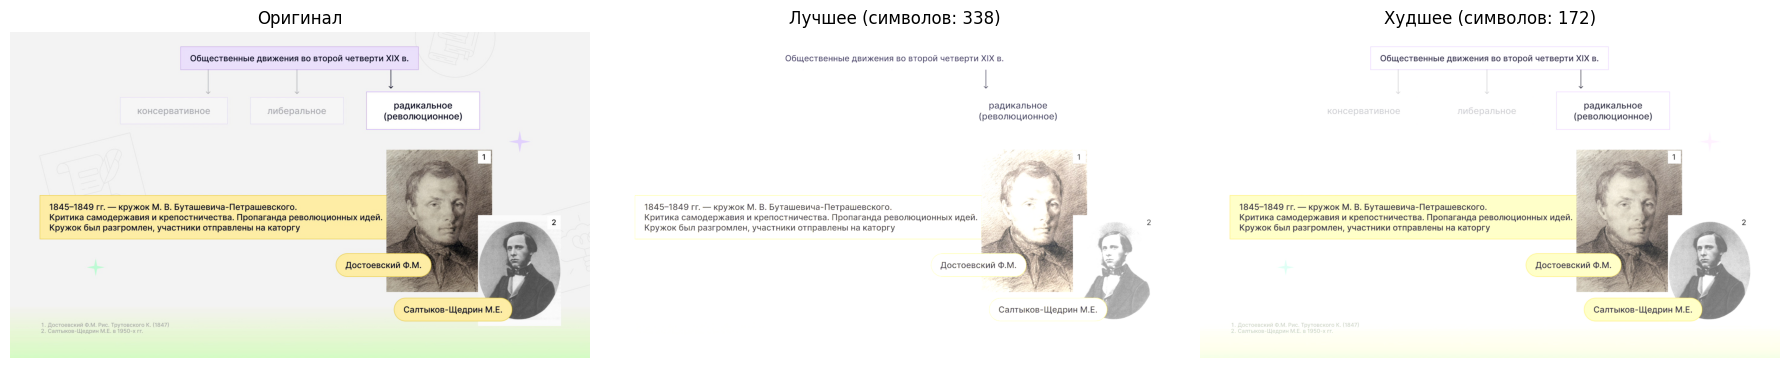

"Лучший текст (символов: 338) α: 1.29, β: 61","Худший текст (символов: 172) α: 0.94, β: 46"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу и _ Достоевский Ф.М. > ( Салтыков-Щедрин М.Е. \",Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1. Достоевский Ф.М. Рис. Трутовского К. (1847) 2. Салтыков-Щедрин М.Е. в 1950-х гг.


  0:02:08.450  ₁⡄₁₄⡄₃₀.₀₉₉ keyframe_45.jpg обработан

🔎 Обработка: keyframe_47.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
197 197 197 197 197 197 197 192 205 192 192 198 175 308 310 299 294 299 295 315 315 315 315 319 alpha=0.80
192 192 214 192 192 194 198 175 308 294 301 294 298 295 312 315 315 315 317 319 321 305 330 275 alpha=0.87
208 198 172 308 294 299 294 294 295 312 315 315 315 315 317 319 305 311 330 301 309 316 315 309 alpha=0.94
299 300 294 298 295 312 315 315 315 315 317 317 321 305 330 311 275 315 316 312 276 337 329 322 alpha=1.01
312 315 315 315 315 315 319 319 305 311 331 300 275 309 316 311 277 337 329 329 322 299 301 297 alpha=1.08
315 317 319 321 305 305 330 311 275 315 315 314 308 273 337 330 322 323 319 301 297 297 301 299 alpha=1.15
305 305 330 311 274 320 316 314 308 277 337 329 329 323 299 319 301 297 302

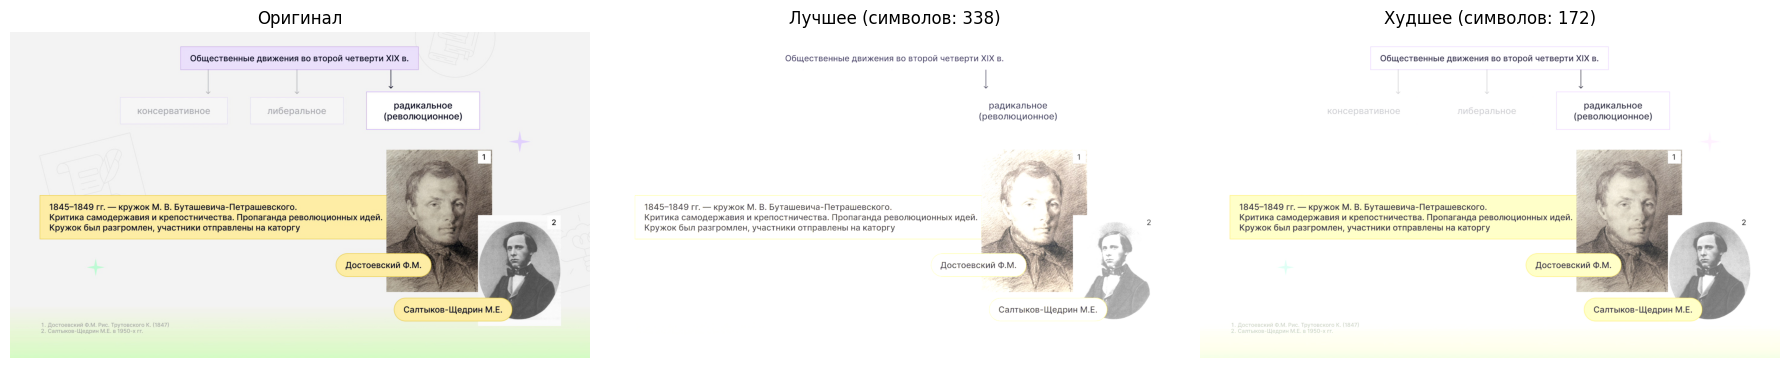

"Лучший текст (символов: 338) α: 1.29, β: 61","Худший текст (символов: 172) α: 0.94, β: 46"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу и _ Достоевский Ф.М. > ( Салтыков-Щедрин М.Е. \",Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1. Достоевский Ф.М. Рис. Трутовского К. (1847) 2. Салтыков-Щедрин М.Е. в 1950-х гг.


  0:02:09.420  ₁⡄₁₆⡄₃₉.₅₂₀ keyframe_47.jpg обработан

🔎 Обработка: keyframe_48.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
284 283 283 284 283 283 283 299 266 284 433 433 433 433 433 433 433 433 433 433 433 433 433 430 alpha=0.80
283 283 299 284 276 433 433 433 433 433 433 433 433 433 433 433 433 433 430 430 430 430 430 430 alpha=0.87
433 433 433 433 433 433 433 433 433 433 433 433 433 433 430 430 430 430 430 430 430 429 430 429 alpha=0.94
433 433 433 433 433 433 433 433 433 433 430 430 430 430 430 430 430 430 430 429 429 429 429 430 alpha=1.01
433 433 433 433 433 430 430 430 430 430 430 430 430 430 429 430 430 429 429 429 426 426 426 427 alpha=1.08
433 430 430 430 430 430 430 430 430 430 430 430 429 429 429 429 430 427 426 427 427 427 427 427 alpha=1.15
430 430 430 430 430 429 430 429 429 429 429 429 430 429 426 426 426 427 426

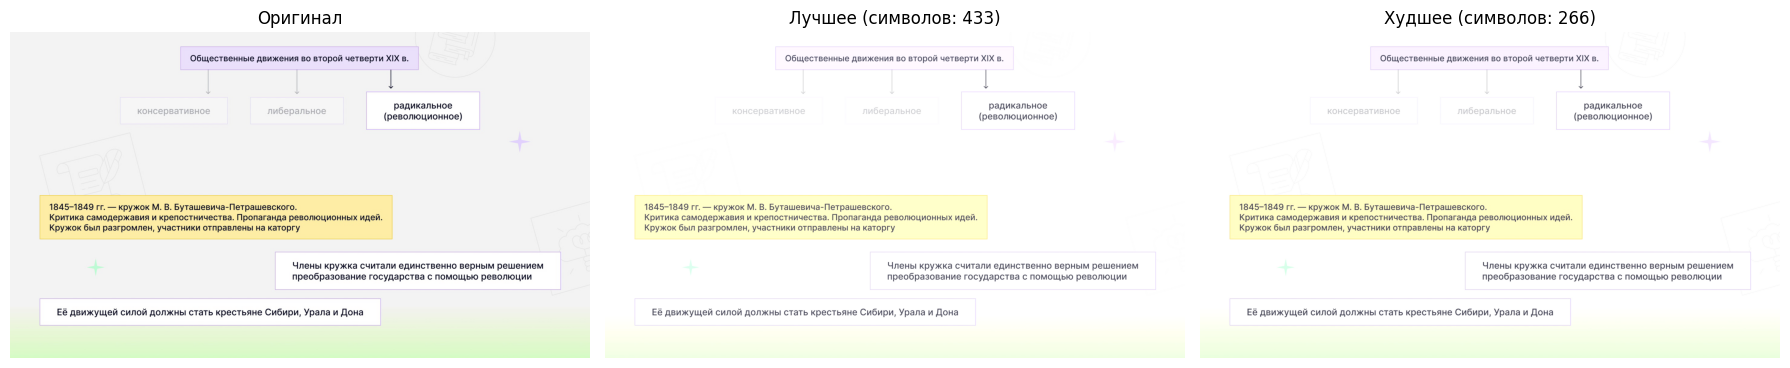

"Лучший текст (символов: 433) α: 0.80, β: 70","Худший текст (символов: 266) α: 0.80, β: 64"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу Члены кружка считали единственно верным решением преобразование государства с помощью революции Её движущей силой должны стать крестьяне Сибири, Урала и Дона","Общественные движения во второй четверти ХИХ в. радикальное (революционное) консервативное либеральное Члены кружка считали единственно верным решением преобразование государства с помощью революции Её движущей силой должны стать крестьяне Сибири, Урала и Дона"


  0:02:20.343  ₁⡄₁₈⡄₅₉.₈₆₄ keyframe_48.jpg обработан

🔎 Обработка: keyframe_49.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
173 173 173 173 173 173 173 173 175 183 163 268 268 268 268 268 268 271 300 271 267 283 271 271 alpha=0.80
173 173 175 183 178 163 268 268 268 268 268 268 268 270 300 289 267 271 267 271 271 271 271 277 alpha=0.87
268 268 268 268 268 268 268 271 270 271 300 289 283 271 271 271 267 271 271 277 315 270 301 267 alpha=0.94
268 268 264 271 270 307 271 267 271 271 271 271 267 271 271 277 318 271 268 267 267 267 267 267 alpha=1.01
299 271 290 285 271 267 271 271 271 271 271 277 313 270 268 267 267 267 267 267 267 267 267 267 alpha=1.08
271 271 271 271 271 271 271 277 316 271 270 268 267 267 267 267 267 267 267 267 267 267 263 267 alpha=1.15
271 271 271 271 317 298 270 268 268 267 267 267 267 267 267 267 267 267 267

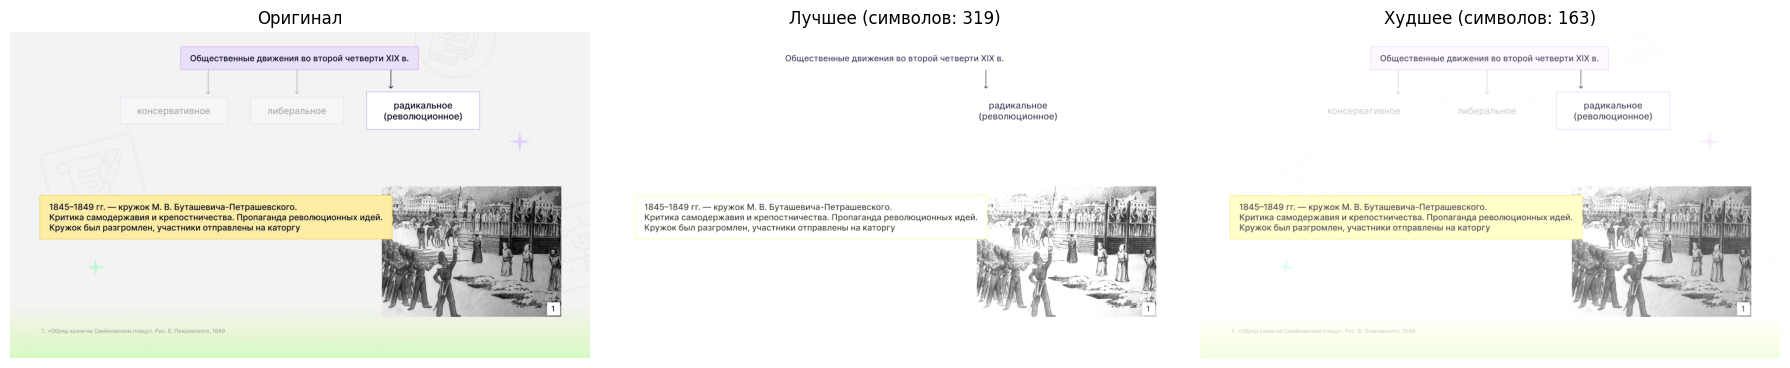

"Лучший текст (символов: 319) α: 1.29, β: 43","Худший текст (символов: 163) α: 0.80, β: 70"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. м Ща ая Критика самодержавия и крепостничества. Пропаганда революционных идей. ы . МИ |& ЕЫ М Кружок был разгромлен, участники отправлены на каторгу аа: па! УТ ВА Тут ТИ","Общественные движения во второй четверти ХИХ в. | радикальное консерва (революционное) 1. «Обряд казни на Семёновском плацу». Рис. Б. Покровского, 1849"


  0:02:07.393  ₁⡄₂₁⡄₀₇.₂₅₇ keyframe_49.jpg обработан

🔎 Обработка: keyframe_50.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
32 32 32 32 19 19 19 36 38 23 23 23 0 0 0 0 0 0 0 0 22 21 17 17 alpha=0.80
19 36 36 22 24 23 0 0 0 0 0 0 0 0 0 0 22 18 17 17 20 21 23 18 alpha=0.87
25 0 0 0 0 0 0 0 0 0 0 0 21 18 17 17 20 20 18 18 37 35 12 7 alpha=0.94
0 0 0 0 0 0 0 22 21 17 17 17 20 22 22 18 18 36 13 7 7 19 19 19 alpha=1.01
0 0 22 22 18 17 17 20 19 22 18 18 18 37 35 7 7 7 7 19 35 35 37 35 alpha=1.08
18 17 17 20 21 20 22 18 37 38 36 7 7 7 19 7 0 35 37 35 35 35 35 35 alpha=1.15
21 20 21 18 18 37 34 10 7 7 7 7 19 19 37 35 35 35 35 35 35 35 35 35 alpha=1.22
18 38 37 10 7 7 7 19 7 0 35 35 35 35 35 35 35 35 35 35 35 35 35 35 alpha=1.29
7 7 7 7 7 19 0 35 37 35 35 35 35 35 35 35 35 35 35 35 35 34 34 35 alpha=1.36
19 7 0 19 35 37 35 35 35 35 35 35 3

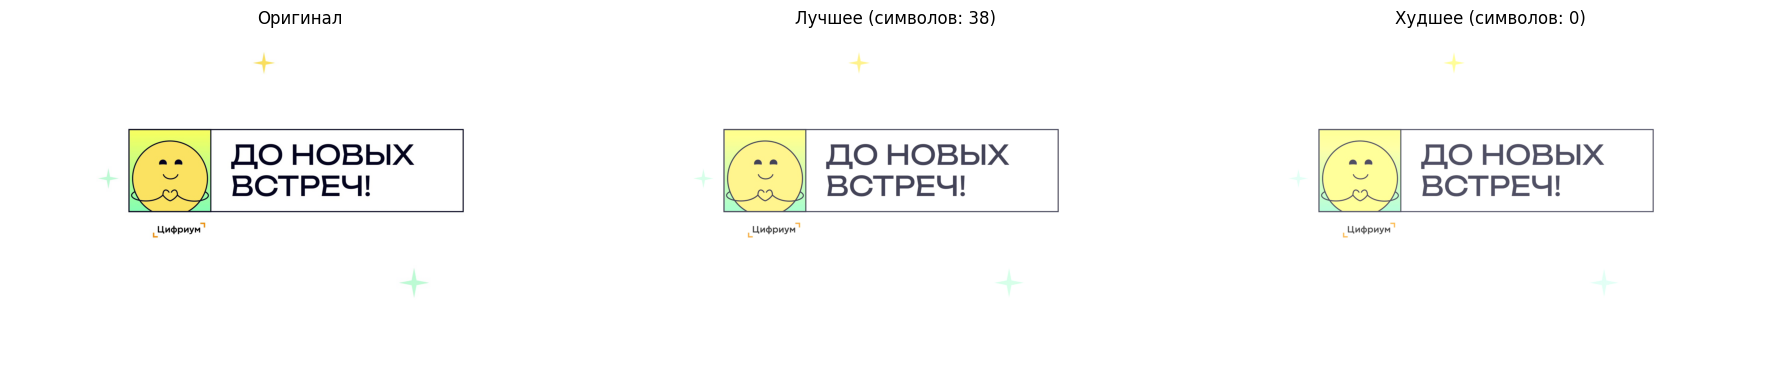

"Лучший текст (символов: 38) α: 0.80, β: 64","Худший текст (символов: 0) α: 0.80, β: 76"
/:—^\ доновых \ = ВСТРЕЧ! - ‚ Цифриум,


  0:01:13.778  ₁⡄₂₂⡄₂₁.₀₃₆ keyframe_50.jpg обработан
  0:00:00.001  ₁⡄₂₂⡄₂₁.₀₃₇ 🏁 Готово


datetime.datetime(2025, 4, 27, 8, 56, 2, 928963)

In [160]:
import os
import cv2
import numpy as np
import glob
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML


# Путь к изображениям
folder = r'results/keyframes'
files = glob.glob(os.path.join(folder, "*.jpg"))

# Функция обработки одного изображения
def ocr_alpha_beta(image_path):
    original_pil = Image.open(image_path).convert("RGB")
    original_cv2 = cv2.cvtColor(np.array(original_pil), cv2.COLOR_RGB2BGR)

    best_score = -1
    worst_score = 1e9
    best_params = None
    worst_params = None
    best_text = ""
    worst_text = ""
    _firstscore = None

    
    alpha_values = np.arange(0.8, 1.6, 0.07)
    beta_values = np.arange(40, 111, 3)

    print(f"\n🔎 Обработка: {os.path.basename(image_path)}")
    print(f"{'β':>5}")
    
    for beta in beta_values:
        print(f"{beta:>3} ", end='')
    print("\n" + "--- " * len(beta_values))

    for alpha in alpha_values:
        print(f"{alpha:>4.2f}", end=' ')
        for beta in beta_values:

            adjusted = cv2.convertScaleAbs(original_cv2, alpha=alpha, beta=beta)
            adjusted_pil = Image.fromarray(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
            text = pytesseract.image_to_string(adjusted_pil, lang='rus')
            score = len(text.strip())  # Количество символов в распознанном тексте


            _firstscore = _firstscore if _firstscore else score
    
            
            if score > best_score:
                best_score = score
                best_img = adjusted.copy()
                best_params = (alpha, beta)
                best_text = text.strip()
                
                # _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BBLUE}{ps.WHITE}{score} {ps._}'

            elif score < worst_score:
                worst_score = score
                worst_img = adjusted.copy()
                worst_params = (alpha, beta)
                worst_text = text.strip()
                
                # _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BDRED}{ps.WHITE}{score} {ps._}'
            else: 
                _score =  gradient_bg((score-_firstscore)/2, score) + ' '
            
            print (f'{_score:>3}', end='')


        print (f'alpha={alpha:1.2f}')

    # print("\n✅ ЛУЧШИЕ ПАРАМЕТРЫ:")
    # print(f"Alpha: {best_params[0]:.2f}, Beta: {best_params[1]}, Символов: {best_score}")
    # print("✅ ХУДШИЕ ПАРАМЕТРЫ:")
    # print(f"Alpha: {worst_params[0]:.2f}, Beta: {worst_params[1]}, Символов: {worst_score}")

    # Визуализация
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(cv2.cvtColor(original_cv2, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Оригинал")
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(best_img, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f"Лучшее (символов: {best_score})")
    axs[1].axis('off')

    axs[2].imshow(cv2.cvtColor(worst_img, cv2.COLOR_BGR2RGB))
    axs[2].set_title(f"Худшее (символов: {worst_score})")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

    _b_text = best_text.replace("\n", ' ')
    _w_text = worst_text.replace("\n", ' ')
    
    html_content = f'''
    <table border="1" style="border-collapse: collapse; width: 100%;">
        <tr style="background-color: #eee;">
            <th>Лучший текст (символов: {best_score}) α: {best_params[0]:.2f}, β: {best_params[1]}</th>
            <th>Худший текст (символов: {worst_score}) α: {worst_params[0]:.2f}, β: {worst_params[1]}</th>
        </tr>
        <tr>
            <td style="vertical-align:top; padding: 10px;">{_b_text}</td>
            <td style="vertical-align:top; padding: 10px;">{_w_text}</td>
        </tr>
    </table>
    '''
    display(HTML(html_content))

    

    return {
        "best_score": best_score,
        "worst_score": worst_score,
        "best_params": best_params,
        "worst_params": worst_params,
        "best_text": best_text,
        "worst_text": worst_text
    }

# Обработка всех файлов
tg(f"🚩 Найдено файлов: {len(files)}")
tm(f"🚩 Найдено файлов: {len(files)}")

for path in files:
    result = ocr_alpha_beta(path)
    tm(f"{os.path.basename(path)} обработан")
    tg(f"{os.path.basename(path)} обработан", tags=str(result))

tm("🏁 Готово")


In [122]:
import cv2
from PIL import Image
import pytesseract
import numpy as np
import glob

tm()

# Путь к изображению

def ocr_alpha_beta(image_path = r'results\keyframes\keyframe_08.jpg'):
    
    
    # Если нужно — указать путь к tesseract
    # pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
    
    # Оригинал изображения
    original_pil = Image.open(image_path).convert("RGB")
    original_cv2 = cv2.cvtColor(np.array(original_pil), cv2.COLOR_RGB2BGR)
    
    best_score = 0
    best_params = (1.0, 0)
    
    # Диапазоны перебора
    alpha_values = np.arange(0.8, 1.6, 0.5)  # Яркость/контрастность Δ 0.05
    beta_values = np.arange(40, 111, 8)           # Смещение яркости Δ 2
    
    print("⏳ Идёт перебор параметров...")
    
    
    for  beta in beta_values:
            print (f'{beta:>3}', end=' ')
    print("")
    print("--- "*len(beta_values))
    
    _firstscore = None
    score_max = 0
    score_min = 1e5
    
    for n, alpha in enumerate(alpha_values):
        
        for beta in beta_values:
                
            adjusted = cv2.convertScaleAbs(original_cv2, alpha=alpha, beta=beta)
            adjusted_pil = Image.fromarray(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
            text = pytesseract.image_to_string(adjusted_pil, lang='rus')
            score = len(text.strip())  # Количество символов в распознанном тексте
            
            _firstscore = _firstscore if _firstscore else score
    
            
            if score > score_max:
                score_max = score
                _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BBLUE}{ps.WHITE}{score} {ps._}'

            elif score < score_min:
                score_min = score 
                _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BDRED}{ps.WHITE}{score} {ps._}'
            else: 
                _score =  gradient_bg((score-_firstscore)/2, score) + ' '
            
            print (f'{_score:>3}', end='')
    
            if score > best_score:
                best_score = score
                best_params = (alpha, beta)
                best_text = text
        print (f'alpha={alpha:1.2f}')
    
    print("\n✅ Оптимальные параметры:")
    print(f"Яркость/Контрастность (alpha): {best_params[0]:.2f}")
    print(f"Смещение яркости (beta): {best_params[1]}")
    print(f"Количество распознанных символов: {best_score}")
    
    print("\n📄 Лучший распознанный текст:\n")
    print(best_text.replace("\n"," ",))
    
    # Если хочешь сохранить лучшую версию изображения:
    best_adjusted = cv2.convertScaleAbs(original_cv2, alpha=best_params[0], beta=best_params[1])
    _adjusted_path = rf" сохранено в [{os.path.basename(image_path)}]"
    
    cv2.imwrite(_adjusted_path, best_adjusted)
    print(f"\n💾 Лучшая версия изображения сохранена в файл best_adjusted{_adjusted_path}")


_files = glob.glob(r'results\keyframes\*')

print(len(_files))

for f in _files:
    tm(f'=========== {ps.BLGREEN} {f} {ps._}==================')
    ocr_alpha_beta(image_path)

    
tm()

 *** Start at: 06:18:08 2025-04-27  ****************************************
29
  0:00:00.001  ₀⡄₀₀⡄₀₀.₀₀₁ ===========  results\keyframes\keyframe_04.jpg ==================
⏳ Идёт перебор параметров...
 40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106 108 110 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
449 449 449 449 449 449 449 449 449 449 449 443 443 443 444 444 444 442 442 445 445 460 460 460 460 459 459 451 457 449 449 456 450 448 457 458 alpha=0.80
449 449 449 449 449 443 443 444 444 444 444 442 442 445 445 445 460 445 460 460 460 459 451 457 449 449 456 454 449 458 459 460 461 448 450 442 alpha=0.85
443 444 444 444 444 442 442 445 445 445 460 460 460 445 460 460 451 451 457 449 449 456 453 456 457 458 460 461 451 450 449 441 453 452 449 439 alpha=0.90
444 442 445 445 460 460 460 445 460 460 459


KeyboardInterrupt



In [17]:
from PIL import Image
import pytesseract

# Если нужно — раскомментируй и укажи путь
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

image_path = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\keyframe_08.jpg'

img = Image.open(image_path).convert("RGB")
text = pytesseract.image_to_string(img, lang='rus')
print("📄 Распознанный текст:\n")
print(text)

📄 Распознанный текст:

Общественные движения во второй четверти ХИХ в.

| |

консервативное либеральное

радикальное
(революционное)

 



### 03. Распознавание слайда с разбиением на блоки 

Требует точных настроек корнтрастности, яркости, на практике этот вариант сложно быдет применять

📋 Найдено блоков текста: 13


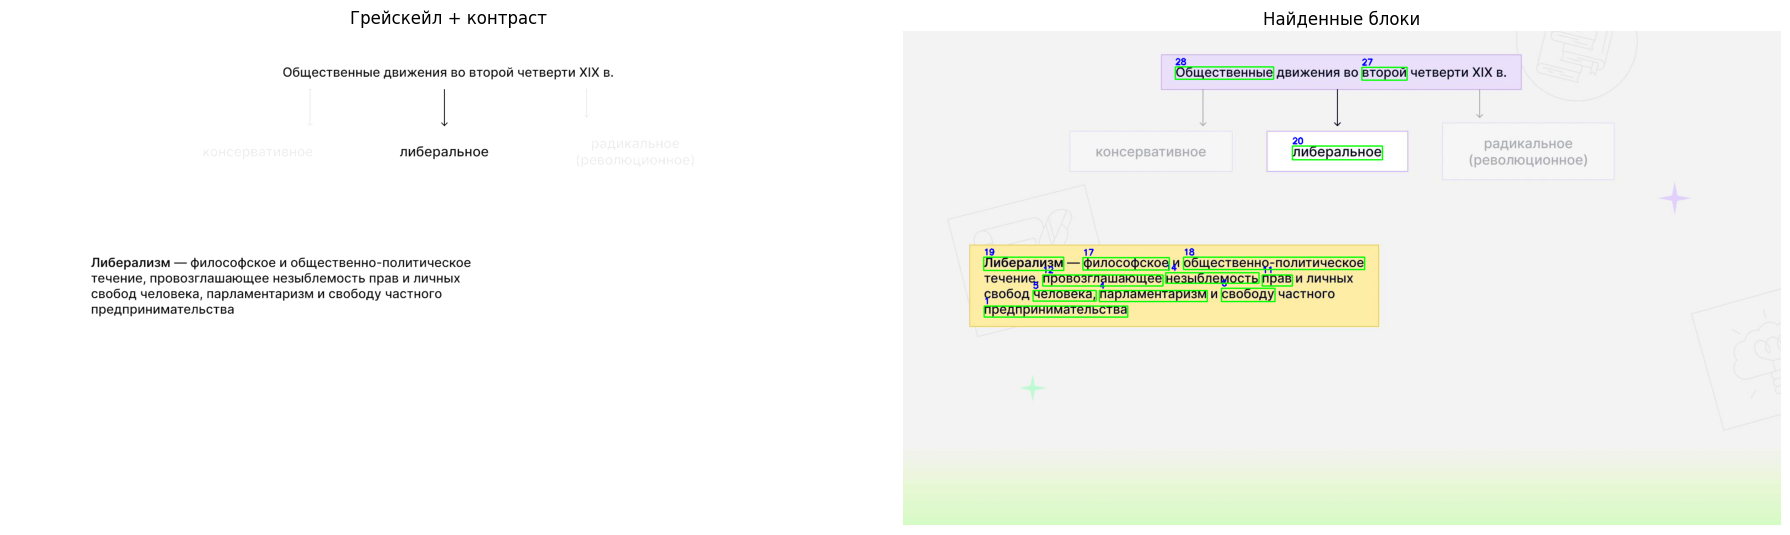

1   | предпринимательства
2   | парламентаризм
3   | человека,
4   | свободу
5   | прав
6   | провозглашающее
7   | незыблемость
8   | философское
9   | общественно-политическое
10  | Либерализм
11  | либеральное
12  | второй
13  | Общественные


In [13]:
import os
import cv2
import pytesseract
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe' # Пример

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def ocr_block_2(image_path, alpha=1.1, beta=50, min_width=100, min_height=30):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл не найден: {image_path}")

    # img = cv2.imread(image_path)

    pil_image = Image.open(image_path)
    img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    
    if img is None:
        raise ValueError("Ошибка при загрузке изображения")

    original = img.copy()

    # Грейскейл и осветление
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

    # Размытие и порог
    blurred = cv2.GaussianBlur(adjusted, (3, 3), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Морфология
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result_img = original.copy()
    recognized_blocks = []

    for n, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)

        if w < min_width or h < min_height:
            continue

        roi = img[y:y+h, x:x+w]
        roi_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        text = pytesseract.image_to_string(roi_pil, lang='rus').strip()

        if text:
            recognized_blocks.append(((x, y, w, h), text))
            cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(result_img, f"{n+1}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    records = [
        {"id": i + 1, "text": text, "x": x, "y": y}
        for i, ((x, y, w, h), text) in enumerate(recognized_blocks)
    ]

    print(f"📋 Найдено блоков текста: {len(records)}")

    # Показываем этапы
    plt.figure(figsize=(18, 6))
    
    # plt.subplot(1, 3, 1)
    
    # plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    # plt.title("Оригинал")
    # plt.axis("off")
    
    plt.subplot(1, 2, 1)
    plt.imshow(adjusted, cmap='gray')
    plt.title("Грейскейл + контраст")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title("Найденные блоки")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    return records


fname = '02.jpg'
fname = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\keyframe_03.jpg'

blocks = ocr_block_2(
    fname,
    alpha=1.1,
    beta=50,
    min_width=20,
    min_height=20
)

for b in blocks:
    print(f"{b['id']:<3} | {b['text']}") 

In [ ]:
{'id': 1, 'text': 'демократические', 'x': 328, 'y': 902}